# Diagnóstico de calidad, adecuación, cobertura y limitaciones de los datos

**Proyecto de Aprendizaje Automático (PAA) — UTEC / LIDIA 2026 · Predicción de siniestros viales**

Produce la evidencia que respalda el diagnóstico de datos exigido por el Entregable 2 de la guía
PAA (sección 5.2) y la sección *Metodología — datos* del informe (guía 6.1: calidad, cobertura,
representatividad, sesgos y restricciones de uso).

**Qué responde**

| Eje | Pregunta |
|---|---|
| Calidad | ¿Los registros son completos, consistentes y precisos para lo que se les va a pedir? |
| Cobertura | ¿Qué territorio, qué período y qué fracción de la unidad de análisis observan realmente? |
| Adecuación | ¿La variable objetivo y las variables disponibles sostienen el problema planteado? |
| Limitaciones | ¿Qué no puede afirmarse con estos datos y qué riesgos introduce cada decisión? |

**Alcance: Montevideo, julio de 2021 a diciembre de 2025, por municipios.** Se diagnostican las
tres fuentes que alimentan el conjunto de modelado: el CSV crudo de siniestros heredado del PID,
la capa de **municipios** de la Intendencia y la serie climática de Open-Meteo. La unidad de
análisis es **(día, municipio)**.

Las dos decisiones de alcance que fija esta versión se justifican con evidencia dentro del
notebook, no por decreto:

| Decisión | Dónde se justifica |
|---|---|
| La zona pasa de **barrio (62)** a **municipio (8)** | secciones 2.6, 3.2 y 4.4 |
| La serie empieza el **2021-07-01**, no el 2021-01-01 | sección 3.1 |

**Todo se recalcula desde las fuentes crudas**, incluida la asignación de cada siniestro a su
municipio. El diagnóstico no depende de que `data/processed/` esté construido; cuando lo está, la
sección 5 lo usa para **contrastar** su propia reconstrucción contra la salida del ETL. Esto lo
convierte en una verificación independiente de
[`preparacion_montevideo.ipynb`](preparacion_montevideo.ipynb), y no en un resumen de ella.

El notebook es de **solo lectura** sobre `data/`: no escribe ni reescribe ningún conjunto.

**Qué deja como artefacto.** Todas las tablas y figuras se escriben en
`experiments/diagnostico_datos/`, de modo que cada cifra citada en el informe pueda rastrearse
hasta un archivo del repositorio.

> **Nota sobre los alcances anteriores.** Este notebook diagnosticó primero el país entero con
> celdas de 1 km (hasta 2026-09-02) y después Montevideo por barrios desde enero de 2021
> (2026-09-04). **Las cifras de ambas versiones están superadas y no deben citarse.** El cambio
> no es cosmético: al pasar de 62 barrios a 8 municipios el porcentaje de ceros del panel cae de
> 71,96 % a 8,60 %, y las conclusiones sobre señal temporal y sobre el aporte de cada bloque de
> variables **cambian de signo**. Todo lo que sobrevive al cambio se vuelve a calcular aquí;
> nada se hereda.


## 0. Configuración y trazabilidad de las fuentes

In [1]:
import hashlib
import importlib.metadata as md_meta
import json
import platform
import sys
import unicodedata
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import holidays
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Polygon as PolyPatch
from matplotlib.path import Path as RutaPoligono
from pyproj import Transformer

# Raíz del repo: funciona sin importar desde dónde se abra el notebook
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").is_dir())
DIR_CRUDO = RAIZ / "data" / "raw"
DIR_PROC = RAIZ / "data" / "processed"
RUTA_CSV = DIR_CRUDO / "uru_siniestros_unificado.csv"
RUTA_CLIMA = DIR_CRUDO / "clima_montevideo.csv"

DIR_SALIDA = RAIZ / "experiments" / "diagnostico_datos"
DIR_TABLAS = DIR_SALIDA / "tablas"
DIR_FIGURAS = DIR_SALIDA / "figuras"
for d in (DIR_TABLAS, DIR_FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

# ── Alcance diagnosticado. Debe coincidir con preparacion_montevideo.ipynb ──
DEPARTAMENTO = "MONTEVIDEO"

# Inicio de la serie. El 1.er semestre de 2021 se excluye por régimen de pandemia: la
# evidencia que lo justifica está en la sección 3.1, calculada sobre el período completo
# desde FECHA_INICIO_CRUDA. No cambiar una de las dos fechas sin releer esa sección.
FECHA_INICIO_CRUDA = "2021-01-01"   # sólo para medir el efecto de la pandemia
FECHA_INICIO = "2021-07-01"         # inicio efectivo del período diagnosticado

CRS_ORIGEN, CRS_DESTINO = "EPSG:32721", "EPSG:4326"

# Zonificación: municipios de Montevideo (8 polígonos). El campo del nombre en la capa de
# la Intendencia es `municipio` y trae la letra sola ("A", "CH"); se le antepone el prefijo
# para que la etiqueta se lea sin contexto en tablas y figuras.
PATRONES_ZONAS = ["*municipio*.geojson", "*municipio*.json", "*municipio*.zip", "*municipio*.shp"]
CAMPOS_NOMBRE = ["MUNICIPIO", "municipio", "NOMBRE", "nombre", "name"]
PREFIJO_ZONA = "MUNICIPIO "
ZONA = "municipio"          # etiqueta de la unidad espacial, para columnas y títulos

CATEGORIAS_FERIADO = ("public", "bank")
SEMILLA = 42

rng = np.random.default_rng(SEMILLA)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9,
})


def guardar_tabla(tabla, nombre, indice=False):
    """Escribe la tabla como CSV en experiments/ y la muestra en el notebook."""
    destino = DIR_TABLAS / f"{nombre}.csv"
    tabla.to_csv(destino, index=indice, encoding="utf-8")
    print(f"[tabla]  {destino.relative_to(RAIZ)}")
    display(tabla)


def guardar_figura(fig, nombre):
    destino = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(destino)
    print(f"[figura] {destino.relative_to(RAIZ)}")


Las tres fuentes se identifican por su *hash*. Si alguna se actualiza, el `sha256` cambia y las
cifras de este diagnóstico dejan de corresponder: es lo que permite detectar que hay que
volver a ejecutarlo.

In [2]:
def buscar_capa_zonas():
    """Primera capa de municipios encontrada en data/raw/, según PATRONES_ZONAS."""
    for patron in PATRONES_ZONAS:
        for ruta in sorted(DIR_CRUDO.glob(patron)):
            return ruta
    return None


RUTA_ZONAS = buscar_capa_zonas()
if RUTA_ZONAS is None:
    raise FileNotFoundError(
        "No se encontró la capa de municipios en data/raw/. El diagnóstico la necesita: "
        "ver la sección 2.6 para el servicio y la consulta exacta con que se obtuvo."
    )

FUENTES = [("siniestros", RUTA_CSV), ("municipios", RUTA_ZONAS), ("clima", RUTA_CLIMA)]
filas = []
for nombre, ruta in FUENTES:
    if not ruta.exists():
        filas.append((nombre, str(ruta.relative_to(RAIZ)), "AUSENTE", "", ""))
        continue
    filas.append((
        nombre, str(ruta.relative_to(RAIZ)), f"{ruta.stat().st_size / 1e6:.2f} MB",
        hashlib.sha256(ruta.read_bytes()).hexdigest(),
        datetime.fromtimestamp(ruta.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
    ))

procedencia = pd.DataFrame(filas, columns=["fuente", "archivo", "tamaño", "sha256", "modificado"])
paquetes = ["pandas", "numpy", "matplotlib", "holidays", "pyproj", "pyshp"]
entorno = pd.DataFrame(
    [("ejecutado", datetime.now(timezone.utc).astimezone().strftime("%Y-%m-%d %H:%M")),
     ("python", f"{sys.version.split()[0]} · {platform.system()} {platform.release()}")]
    + [(p, md_meta.version(p)) for p in paquetes], columns=["clave", "valor"])

guardar_tabla(procedencia, "00_procedencia")
guardar_tabla(entorno, "00b_entorno")


[tabla]  experiments\diagnostico_datos\tablas\00_procedencia.csv


,fuente,archivo,tamaño,sha256,modificado
0,siniestros,data\raw\uru_siniestros_unificado.csv,26.19 MB,48a8a7e8f06ed8aa1d138b9921995d81a2c86cb3858354...,2026-08-24 11:21
1,municipios,data\raw\municipios_montevideo.geojson,2.87 MB,ed0ba13e53b08f1e35eead16ffdef16d57e518aff30c7c...,2026-09-07 13:36
2,clima,data\raw\clima_montevideo.csv,0.08 MB,f40e6c3ccdeeb87aae40dcc5a9b685aa7471aefe50f446...,2026-09-02 10:30


[tabla]  experiments\diagnostico_datos\tablas\00b_entorno.csv


,clave,valor
0,ejecutado,2026-09-07 14:28
1,python,3.13.2 · Windows 10
2,pandas,3.0.5
3,numpy,2.5.2
4,matplotlib,3.11.1
5,holidays,0.103
6,pyproj,3.7.2
7,pyshp,3.1.6


## 1. Fuente, unidad de análisis y disponibilidad de las variables

In [3]:
# skipinitialspace: el CSV trae un espacio después de cada coma; los encabezados también
df_pais = pd.read_csv(RUTA_CSV, skipinitialspace=True, encoding="utf-8")
df_pais.columns = df_pais.columns.str.strip()
df_pais["Fecha"] = pd.to_datetime(df_pais["Fecha"], format="%m/%d/%Y")
for c in df_pais.select_dtypes(include="object").columns:
    df_pais[c] = df_pais[c].astype(str).str.strip()

COLS_CRUDAS = list(df_pais.columns)
print(f"archivo completo: {len(df_pais):,} registros × {len(COLS_CRUDAS)} columnas")
print(f"período del archivo: {df_pais['Fecha'].min():%Y-%m-%d} → {df_pais['Fecha'].max():%Y-%m-%d}")

esquema = pd.DataFrame({
    "tipo": df_pais.dtypes.astype(str),
    "no_nulos": df_pais.notna().sum(),
    "distintos": df_pais.nunique(),
    "ejemplo": df_pais.iloc[0].astype(str),
}).reset_index(names="columna")
guardar_tabla(esquema, "01_esquema_crudo")

archivo completo: 224,694 registros × 11 columnas
período del archivo: 2018-01-01 → 2025-12-31
[tabla]  experiments\diagnostico_datos\tablas\01_esquema_crudo.csv


C:\Users\victo\AppData\Local\Temp\ipykernel_11168\1312465157.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_pais.select_dtypes(include="object").columns:


,columna,tipo,no_nulos,distintos,ejemplo
0,Fecha,datetime64[us],224694,2922,2018-07-24 00:00:00
1,Calle,str,224693,23746,AVENIDA DIECIOCHO DE JULIO
2,Tipo de Siniestro,str,224694,9,ATROPELLO DE PEATÓN
3,Gravedad,str,224694,4,LEVE
4,Dia Semana,str,224694,7,MARTES
5,Hora,int64,224694,24,16
6,Departamento,str,224694,19,MONTEVIDEO
7,Localidad,str,224694,455,MONTEVIDEO
8,fixed,int64,224694,1,1
9,X,int64,224694,35532,575370


### 1.1 Recorte al alcance del proyecto

El archivo heredado del PID cubre el país entero desde 2018. El proyecto se acotó a **Montevideo**
tras la reunión de seguimiento, y el inicio de la serie se fijó en **julio de 2021** para dejar
fuera el semestre con régimen de movilidad de pandemia (la evidencia está en la sección 3.1).

El recorte se hace en dos etapas y las dos quedan a la vista. Se conserva además el tramo
**enero–junio de 2021** en un marco aparte (`df_previo`): no entra en el diagnóstico, pero es el
material con el que la sección 3.1 demuestra que corresponde excluirlo. Descartarlo aquí dejaría
esa decisión sin respaldo verificable.


In [4]:
pasos = [("registros del archivo", len(df_pais))]
sel = df_pais[df_pais["Departamento"] == DEPARTAMENTO]
pasos.append((f"tras filtrar {DEPARTAMENTO}", len(sel)))

sel_crudo = sel[sel["Fecha"] >= pd.Timestamp(FECHA_INICIO_CRUDA)]
pasos.append((f"tras filtrar fecha >= {FECHA_INICIO_CRUDA}", len(sel_crudo)))

sel = sel_crudo[sel_crudo["Fecha"] >= pd.Timestamp(FECHA_INICIO)]
pasos.append((f"tras excluir el 1.er semestre de 2021 (>= {FECHA_INICIO})", len(sel)))

df = sel.copy().reset_index(drop=True)                 # base del diagnóstico, sin deduplicar
# Tramo excluido, sólo para justificar la exclusión en la sección 3.1
df_previo = sel_crudo[sel_crudo["Fecha"] < pd.Timestamp(FECHA_INICIO)].copy().reset_index(drop=True)

recorte = pd.DataFrame(pasos, columns=["paso", "registros"])
recorte["pct_del_archivo"] = (100 * recorte["registros"] / len(df_pais)).round(1)
guardar_tabla(recorte, "02_recorte_alcance")

FECHA_FIN = df["Fecha"].max()
DIAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq="D")
print(f"\nperíodo diagnosticado: {DIAS[0]:%Y-%m-%d} → {DIAS[-1]:%Y-%m-%d} ({len(DIAS):,} días)")
print(f"tramo excluido por pandemia: {FECHA_INICIO_CRUDA} → "
      f"{pd.Timestamp(FECHA_INICIO) - pd.Timedelta(days=1):%Y-%m-%d} "
      f"({len(df_previo):,} registros, se analizan en 3.1)")


[tabla]  experiments\diagnostico_datos\tablas\02_recorte_alcance.csv


,paso,registros,pct_del_archivo
0,registros del archivo,224694,100.0
1,tras filtrar MONTEVIDEO,62427,27.8
2,tras filtrar fecha >= 2021-01-01,39676,17.7
3,tras excluir el 1.er semestre de 2021 (>= 2021...,36713,16.3



período diagnosticado: 2021-07-01 → 2025-12-31 (1,645 días)
tramo excluido por pandemia: 2021-01-01 → 2021-06-30 (2,963 registros, se analizan en 3.1)


### 1.2 Unidad de análisis y disponibilidad temporal de las variables

La unidad es **(día, municipio)** y la variable objetivo es el **conteo de siniestros** en esa
combinación. La pregunta que gobierna la tabla siguiente es la que exige la guía (6.1): *¿esta
columna está disponible en el momento real de la predicción?* Todo lo que describe el siniestro
—hora, tipo, gravedad— **existe sólo después de que ocurrió**, así que no puede ser variable
predictora: sería mirar la respuesta. Se conserva en el diagnóstico como caracterización de la
fuente, no como insumo del modelo.


In [5]:
# La clasificación es una decisión del equipo, no un cálculo: se versiona como tabla para
# poder citarla y discutirla.
roles = pd.DataFrame(
    [
        ("Fecha", "día del siniestro", "sí", "eje temporal de la unidad de análisis"),
        ("X, Y", "coordenadas UTM 21S del siniestro", "sí", "definen el municipio por intersección"),
        ("Departamento", "atributo territorial", "sí", "sólo para el recorte; constante después"),
        ("Localidad", "atributo territorial", "parcial", "faltante encubierto; la zona sale del polígono"),
        ("Calle", "texto libre del lugar", "parcial", "alta cardinalidad; no se usa"),
        ("Dia Semana", "derivable de Fecha", "sí", "se usa para verificar el formato de fecha (2.3)"),
        ("Hora", "hora del siniestro ocurrido", "no", "posterior al evento; la unidad es el día"),
        ("Tipo de Siniestro", "clasificación del siniestro ocurrido", "no", "posterior al evento"),
        ("Gravedad", "consecuencia del siniestro ocurrido", "no", "posterior al evento"),
        ("fixed", "marca del proceso ETL del PID", "no", "constante: sin información"),
    ],
    columns=["columna", "qué es", "disponible antes del evento", "uso en el PAA"],
)
guardar_tabla(roles, "03_disponibilidad_variables")

exogenas = pd.DataFrame(
    [("clima (Open-Meteo)", "archivo histórico reanalizado", "sí",
      "disponible para cualquier fecha pasada; en producción exige pronóstico"),
     ("tipo_dia (calendario)", "entre_semana / fin_semana / feriado", "sí",
      "determinista: se conoce con años de anticipación")],
    columns=["variable exógena", "qué es", "disponible antes del evento", "observación"],
)
guardar_tabla(exogenas, "03b_disponibilidad_exogenas")


[tabla]  experiments\diagnostico_datos\tablas\03_disponibilidad_variables.csv


,columna,qué es,disponible antes del evento,uso en el PAA
0,Fecha,día del siniestro,sí,eje temporal de la unidad de análisis
1,"X, Y",coordenadas UTM 21S del siniestro,sí,definen el municipio por intersección
2,Departamento,atributo territorial,sí,sólo para el recorte; constante después
3,Localidad,atributo territorial,parcial,faltante encubierto; la zona sale del polígono
4,Calle,texto libre del lugar,parcial,alta cardinalidad; no se usa
5,Dia Semana,derivable de Fecha,sí,se usa para verificar el formato de fecha (2.3)
6,Hora,hora del siniestro ocurrido,no,posterior al evento; la unidad es el día
7,Tipo de Siniestro,clasificación del siniestro ocurrido,no,posterior al evento
8,Gravedad,consecuencia del siniestro ocurrido,no,posterior al evento
9,fixed,marca del proceso ETL del PID,no,constante: sin información


[tabla]  experiments\diagnostico_datos\tablas\03b_disponibilidad_exogenas.csv


,variable exógena,qué es,disponible antes del evento,observación
0,clima (Open-Meteo),archivo histórico reanalizado,sí,disponible para cualquier fecha pasada; en pro...
1,tipo_dia (calendario),entre_semana / fin_semana / feriado,sí,determinista: se conoce con años de anticipación


De once columnas del archivo, sólo **`Fecha`, `X` e `Y`** construyen la unidad de análisis y la
variable objetivo. Las tres columnas que describen el siniestro (`Hora`, `Tipo de Siniestro`,
`Gravedad`) son informativas para caracterizar la fuente pero **inutilizables como predictoras**.

La fila del clima merece una advertencia que el informe debe recoger: aquí se usa el **archivo
histórico reanalizado** de Open-Meteo, que para una fecha pasada da la observación. Un sistema en
producción no tendría eso, sino un **pronóstico**, con su propio error. El desempeño medido con
clima observado es, por tanto, una **cota optimista** del desempeño operativo.

## 2. Calidad

### 2.1 Completitud: nulos explícitos y faltantes encubiertos

El archivo no trae valores nulos: los faltantes vienen **codificados como texto** (`SIN DATOS` y
variantes). Contarlos como categoría sería subestimar el problema, así que se los busca
explícitamente. Se informa el país y el recorte por separado, porque la diferencia entre ambos es
en sí misma un resultado.

In [6]:
CENTINELAS = ("SIN DATOS", "NO SE INGRESO", "NO SE INGRESÓ", "SIN DATO")

filas = []
for col in df_pais.select_dtypes(include="object").columns:
    filas.append({
        "columna": col,
        "nulos": int(df[col].isna().sum()),
        "centinela_pais_%": round(100 * df_pais[col].isin(CENTINELAS).mean(), 2),
        "centinela_mvd_n": int(df[col].isin(CENTINELAS).sum()),
        "centinela_mvd_%": round(100 * df[col].isin(CENTINELAS).mean(), 2),
    })
completitud = pd.DataFrame(filas).sort_values("centinela_mvd_%", ascending=False)
guardar_tabla(completitud, "04_completitud")

[tabla]  experiments\diagnostico_datos\tablas\04_completitud.csv


C:\Users\victo\AppData\Local\Temp\ipykernel_11168\2376962209.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_pais.select_dtypes(include="object").columns:


,columna,nulos,centinela_pais_%,centinela_mvd_n,centinela_mvd_%
5,Localidad,0,17.91,1646,4.48
0,Calle,0,12.37,854,2.33
1,Tipo de Siniestro,0,0.01,10,0.03
2,Gravedad,0,0.00,0,0.00
3,Dia Semana,0,0.00,0,0.00
4,Departamento,0,0.00,0,0.00


El recorte a Montevideo **mejora sustancialmente la completitud**: las columnas afectadas por
faltantes encubiertos lo están mucho menos que en el país. El problema de calidad que dominaba el
diagnóstico nacional era, en buena medida, un problema del interior.

Ninguna de las columnas afectadas se usa como predictora —el municipio sale de la geometría, no
del texto de `Localidad`—, de modo que **no corresponde imputar**: los faltantes están en campos
descriptivos que el modelo no consume. Se declara el conteo en lugar de omitirlo.


### 2.2 Duplicados

Se cuentan como duplicados las filas idénticas en **todas** las columnas del archivo. Sin
identificador de siniestro no hay forma de distinguir con certeza un duplicado de carga de dos
siniestros reales con los mismos atributos; el peso de la evidencia lo da el tamaño del grupo
mayor.

In [7]:
dup_pais = df_pais.duplicated()
dup_mvd = df.duplicated()
grupos = df[df.duplicated(keep=False)].groupby(list(df.columns), dropna=False).size()

duplicados = pd.DataFrame(
    [("duplicados exactos en el archivo", f"{int(dup_pais.sum()):,}",
      f"{100 * dup_pais.mean():.2f} %"),
     ("duplicados exactos en el recorte", f"{int(dup_mvd.sum()):,}",
      f"{100 * dup_mvd.mean():.2f} %"),
     ("grupos con repetición (recorte)", f"{len(grupos):,}", ""),
     ("repeticiones en el grupo mayor", f"{int(grupos.max()) if len(grupos) else 0}", "")],
    columns=["indicador", "valor", "proporción"],
)
guardar_tabla(duplicados, "05_duplicados")

# Efecto sobre la cola alta del objetivo: el máximo por (día, municipio) antes y después
df_dedup = df.drop_duplicates().reset_index(drop=True)
print(f"\nregistros tras deduplicar el recorte: {len(df_dedup):,}")


[tabla]  experiments\diagnostico_datos\tablas\05_duplicados.csv


,indicador,valor,proporción
0,duplicados exactos en el archivo,347,0.15 %
1,duplicados exactos en el recorte,90,0.25 %
2,grupos con repetición (recorte),71,
3,repeticiones en el grupo mayor,10,



registros tras deduplicar el recorte: 36,623


El grupo mayor concentra varias copias byte a byte del **mismo** registro. Un siniestro no se
repite diez veces en la misma esquina, a la misma hora, con el mismo tipo y la misma gravedad: la
lectura es que se trata de un artefacto de carga, no de eventos distintos.

Su efecto se ve en la cola alta de la variable objetivo (sección 4.1): sin deduplicar, el máximo
de siniestros en un día y un municipio queda inflado por repeticiones. **El resto del diagnóstico
usa el recorte deduplicado.**


### 2.3 Consistencia interna

`Dia Semana` es redundante respecto de `Fecha`, y esa redundancia es útil: permite **verificar el
formato de fecha contra evidencia independiente del propio archivo**. Es una comprobación barata
que evita un error silencioso y grave — `05/06/2021` parsea con `%m/%d/%Y` y con `%d/%m/%Y`, y
da días distintos.

In [8]:
DIAS_ES = {0: "LUNES", 1: "MARTES", 2: "MIERCOLES", 3: "JUEVES",
           4: "VIERNES", 5: "SABADO", 6: "DOMINGO"}


def sin_tildes(serie):
    return serie.str.upper().map(
        lambda s: "".join(c for c in unicodedata.normalize("NFD", s)
                          if unicodedata.category(c) != "Mn"))


crudo_fecha = pd.read_csv(RUTA_CSV, skipinitialspace=True, encoding="utf-8", usecols=["Fecha"])
crudo_fecha = crudo_fecha["Fecha"].astype(str).str.strip()
observado = sin_tildes(df_pais["Dia Semana"])

filas = []
for fmt in ["%m/%d/%Y", "%d/%m/%Y"]:
    parsed = pd.to_datetime(crudo_fecha, format=fmt, errors="coerce")
    coincide = (parsed.dt.dayofweek.map(DIAS_ES) == observado)
    filas.append((fmt, int(parsed.isna().sum()), f"{100 * coincide.mean():.4f} %"))

consistencia = pd.DataFrame(filas, columns=["formato probado", "fechas no parseables",
                                            "coincidencia con 'Dia Semana'"])
guardar_tabla(consistencia, "06_consistencia")

otros = pd.DataFrame(
    [("Hora fuera de 0-23", int((~df_dedup["Hora"].between(0, 23)).sum())),
     ("valores distintos de 'fixed'", int(df_dedup["fixed"].nunique())),
     ("registros con Departamento != MONTEVIDEO", int((df_dedup["Departamento"] != DEPARTAMENTO).sum())),
     ("fechas fuera del período declarado", int((~df_dedup["Fecha"].between(DIAS[0], DIAS[-1])).sum()))],
    columns=["comprobación", "registros"],
)
guardar_tabla(otros, "06b_consistencia_otros")

[tabla]  experiments\diagnostico_datos\tablas\06_consistencia.csv


,formato probado,fechas no parseables,coincidencia con 'Dia Semana'
0,%m/%d/%Y,0,100.0000 %
1,%d/%m/%Y,133356,6.7955 %


[tabla]  experiments\diagnostico_datos\tablas\06b_consistencia_otros.csv


,comprobación,registros
0,Hora fuera de 0-23,0
1,valores distintos de 'fixed',1
2,registros con Departamento != MONTEVIDEO,0
3,fechas fuera del período declarado,0


Un solo formato explica el **100 %** de los días de la semana declarados y el otro falla en la
mayoría de los registros: el archivo es homogéneo y la fecha se parsea sin ambigüedad. Esto
**refuta la suposición del ETL del PID**, que probaba varios formatos en cascada
(`parsear_fecha_mixta`) asumiendo que el archivo los mezclaba.

`fixed` toma un único valor en todo el recorte: no aporta información y no puede usarse como
indicador de calidad de la geocodificación, aunque su nombre lo sugiera.

### 2.4 Precisión espacial

Interesa saber a qué se parecen las coordenadas: si están geocodificadas a la esquina o al tramo
de calle, la asignación a municipio es fiable; si estuvieran volcadas al centroide de la ciudad,
no lo sería.


In [9]:
xy = df_dedup.groupby(["X", "Y"]).size().sort_values(ascending=False)
mult5 = ((df_dedup["X"] % 5 == 0) & (df_dedup["Y"] % 5 == 0)).mean()

precision = pd.DataFrame(
    [("coordenadas múltiplo de 5 m", f"{100 * mult5:.2f} %"),
     ("coordenadas distintas", f"{len(xy):,}"),
     ("siniestros por coordenada (media)", f"{len(df_dedup) / len(xy):.1f}"),
     ("siniestros en la coordenada más repetida", f"{int(xy.iloc[0]):,}"),
     ("… como % del recorte", f"{100 * xy.iloc[0] / len(df_dedup):.2f} %"),
     ("las 10 coordenadas más repetidas concentran", f"{100 * xy.head(10).sum() / len(df_dedup):.2f} %"),
     ("rango X (m)", f"{df_dedup['X'].min():,} – {df_dedup['X'].max():,}"),
     ("rango Y (m)", f"{df_dedup['Y'].min():,} – {df_dedup['Y'].max():,}"),
     ("coordenadas nulas o <= 0", int(((df_dedup["X"] <= 0) | (df_dedup["Y"] <= 0)).sum()))],
    columns=["indicador", "valor"],
)
guardar_tabla(precision, "07_precision_espacial")

[tabla]  experiments\diagnostico_datos\tablas\07_precision_espacial.csv


,indicador,valor
0,coordenadas múltiplo de 5 m,100.00 %
1,coordenadas distintas,"7,833"
2,siniestros por coordenada (media),4.7
3,siniestros en la coordenada más repetida,113
4,… como % del recorte,0.31 %
5,las 10 coordenadas más repetidas concentran,2.01 %
6,rango X (m),"554,380 – 588,320"
7,rango Y (m),"6,134,505 – 6,157,850"
8,coordenadas nulas o <= 0,0


La resolución es de 5 m y los siniestros se reparten entre miles de coordenadas distintas, con
una concentración baja en la más repetida. Ese patrón es el de una geocodificación **a esquina o
tramo de calle**, no a un centroide genérico, y es lo que hace viable la asignación por
intersección punto-polígono de la sección 2.6.

La contrapartida —un punto ajustado a la esquina puede caer del lado equivocado de un límite
cuando ese límite corre por el eje de la calle— **pierde peso con la zonificación por
municipios**: hay 8 fronteras en lugar de 62, y son en su mayoría avenidas y arroyos de gran
porte. La cantidad de casos ambiguos por borde es, por construcción, mucho menor que con barrios.


### 2.5 Validez temporal

In [10]:
por_dia = df_dedup.groupby("Fecha").size().reindex(DIAS, fill_value=0)

validez = pd.DataFrame(
    [("días del período", f"{len(DIAS):,}"),
     ("días sin ningún siniestro", f"{int((por_dia == 0).sum()):,}"),
     ("mínimo diario", int(por_dia.min())),
     ("mediana diaria", float(por_dia.median())),
     ("máximo diario", int(por_dia.max())),
     ("fecha del mínimo", f"{por_dia.idxmin():%Y-%m-%d}"),
     ("fecha del máximo", f"{por_dia.idxmax():%Y-%m-%d}")],
    columns=["indicador", "valor"],
)
guardar_tabla(validez, "08_validez_temporal")

[tabla]  experiments\diagnostico_datos\tablas\08_validez_temporal.csv


,indicador,valor
0,días del período,"1,645"
1,días sin ningún siniestro,0
2,mínimo diario,4
3,mediana diaria,22.0
4,máximo diario,44
5,fecha del mínimo,2022-01-16
6,fecha del máximo,2025-12-11


No hay días vacíos ni saltos en el calendario: la serie diaria del departamento está completa. Un
día sin registros habría sido sospechoso de falla del sistema de carga más que de ausencia real de
siniestros, y no ocurre.

### 2.6 Calidad de la asignación a municipios

La zona sale de una **intersección punto-polígono** entre las coordenadas del siniestro y la capa
de municipios de la Intendencia. No se geocodifica ninguna dirección. Lo que hay que diagnosticar
es cuántos siniestros **no** caen en ningún polígono, y si la capa cubre lo que dice cubrir.

**Procedencia de la capa.** GeoServer institucional de la Intendencia de Montevideo
(`montevideo.gub.uy/app/geoserver`), capa `mapstore-tematicas:zon_v_sig_municipios`
(«Municipios», 8 polígonos: A, B, C, CH, D, E, F y G). Se obtuvo por **WFS** en GeoJSON y se
guardó sin modificar en `data/raw/municipios_montevideo.geojson`. Licencia y condiciones: el
propio `GetCapabilities` declara `Fees: none` y `AccessConstraints: none`.

```
GET https://montevideo.gub.uy/app/geoserver/mapstore-tematicas/zon_v_sig_municipios/ows
    ?service=WFS&version=2.0.0&request=GetFeature
    &typeName=mapstore-tematicas:zon_v_sig_municipios
    &outputFormat=application/json&srsName=EPSG:4326
Header: User-Agent: Mozilla/5.0 (cualquier UA de navegador)
```

Detalle no obvio, por si hay que repetir la descarga: el servicio devuelve **403** ante el
`User-Agent` por omisión de una librería HTTP y **200** con uno de navegador.

El código de lectura y asignación está deliberadamente duplicado respecto de
`preparacion_montevideo.ipynb`: así el diagnóstico verifica la asignación de forma independiente
en lugar de heredarla. Cuando se migre a `src/`, ambos deberían llamar a la misma función.


In [11]:
A_WGS84 = Transformer.from_crs(CRS_ORIGEN, CRS_DESTINO, always_xy=True)
A_UTM = Transformer.from_crs(CRS_DESTINO, CRS_ORIGEN, always_xy=True)


def etiquetar(valor, i):
    """La capa de municipios trae la letra sola; se le antepone el prefijo."""
    v = str(valor).strip()
    if not v:
        return f"zona_{i}"
    return f"{PREFIJO_ZONA}{v}" if len(v) <= 2 else v


def leer_capa(ruta):
    """Devuelve [(nombre, [anillos]), ...] en las unidades del archivo."""
    if ruta.suffix.lower() in (".geojson", ".json"):
        datos = json.loads(ruta.read_text(encoding="utf-8"))
        salida = []
        for i, rasgo in enumerate(datos.get("features", [])):
            props = {k.upper(): v for k, v in (rasgo.get("properties") or {}).items()}
            bruto = next((props[c.upper()] for c in CAMPOS_NOMBRE
                          if c.upper() in props and props[c.upper()]), "")
            nombre = etiquetar(bruto, i)
            geo = rasgo.get("geometry") or {}
            if geo.get("type") == "Polygon":
                polis = [geo["coordinates"]]
            elif geo.get("type") == "MultiPolygon":
                polis = geo["coordinates"]
            else:
                continue
            salida.append((nombre, [np.asarray(a, float)[:, :2] for p in polis for a in p]))
        return salida

    import shapefile  # pyshp
    if ruta.suffix.lower() == ".zip":
        zf = zipfile.ZipFile(ruta)
        base = next(n[:-4] for n in zf.namelist() if n.lower().endswith(".shp"))
        abrir = lambda e: zf.open(base + e) if (base + e) in zf.namelist() else None
        lector = shapefile.Reader(shp=abrir(".shp"), dbf=abrir(".dbf"), shx=abrir(".shx"))
    else:
        lector = shapefile.Reader(str(ruta))
    campos = [c[0] for c in lector.fields[1:]]
    idx = next((campos.index(c) for c in CAMPOS_NOMBRE if c in campos), None)
    salida = []
    for i, sr in enumerate(lector.iterShapeRecords()):
        pts = np.asarray(sr.shape.points, float)
        cortes = list(sr.shape.parts) + [len(pts)]
        anillos = [pts[a:b] for a, b in zip(cortes[:-1], cortes[1:]) if b - a >= 4]
        if anillos:
            salida.append((etiquetar(sr.record[idx] if idx is not None else "", i), anillos))
    return salida


def preparar(capa):
    """Reproyecta a UTM si hace falta y separa anillos exteriores de agujeros."""
    out = []
    for nombre, anillos in capa:
        conv = []
        for a in anillos:
            x, y = a[:, 0], a[:, 1]
            if np.abs(x).max() <= 180 and np.abs(y).max() <= 90:
                x, y = A_UTM.transform(x, y)
            conv.append(np.column_stack([x, y]))
        areas = [abs(np.dot(a[:, 0], np.roll(a[:, 1], 1))
                     - np.dot(a[:, 1], np.roll(a[:, 0], 1))) / 2 for a in conv]
        ext, hue = [], []
        for k in np.argsort(areas)[::-1]:
            anillo = conv[k]
            if any(RutaPoligono(e).contains_point(anillo.mean(axis=0)) for e in ext):
                hue.append(anillo)
            else:
                ext.append(anillo)
        out.append((nombre, [RutaPoligono(e) for e in ext], [RutaPoligono(h) for h in hue]))
    return out


capa = leer_capa(RUTA_ZONAS)
poligonos = preparar(capa)
print(f"capa: {RUTA_ZONAS.name} · {len(capa)} polígonos · "
      f"{len({n for n, _ in capa})} nombres distintos")
print("municipios:", ", ".join(sorted(n for n, _ in capa)))


capa: municipios_montevideo.geojson · 8 polígonos · 8 nombres distintos
municipios: MUNICIPIO A, MUNICIPIO B, MUNICIPIO C, MUNICIPIO CH, MUNICIPIO D, MUNICIPIO E, MUNICIPIO F, MUNICIPIO G


In [12]:
puntos = df_dedup[["X", "Y"]].to_numpy(float)
zona = np.full(len(df_dedup), None, dtype=object)
for nombre, ext, hue in poligonos:
    libre = pd.isna(pd.Series(zona)).to_numpy()
    if not libre.any():
        break
    dentro = np.zeros(len(df_dedup), bool)
    for e in ext:
        dentro |= e.contains_points(puntos)
    for h in hue:
        dentro &= ~h.contains_points(puntos)
    zona[libre & dentro] = nombre

df_dedup = df_dedup.assign(**{ZONA: zona})
sin_zona = df_dedup[ZONA].isna()

calidad_capa = pd.DataFrame(
    [("polígonos en la capa", len(capa)),
     ("nombres distintos", len({n for n, _ in capa})),
     ("municipios con al menos un siniestro", int(df_dedup[ZONA].nunique())),
     ("siniestros asignados", f"{int((~sin_zona).sum()):,}"),
     ("siniestros fuera de todo polígono", f"{int(sin_zona.sum()):,}"),
     ("… como % del recorte", f"{100 * sin_zona.mean():.2f} %")],
    columns=["indicador", "valor"],
)
guardar_tabla(calidad_capa, "09_calidad_capa_municipios")

if sin_zona.any():
    fuera = df_dedup[sin_zona]
    lon, lat = A_WGS84.transform(fuera["X"].to_numpy(float), fuera["Y"].to_numpy(float))
    detalle = pd.DataFrame({"Fecha": fuera["Fecha"].dt.strftime("%Y-%m-%d"),
                            "X": fuera["X"].values, "Y": fuera["Y"].values,
                            "longitud": np.round(lon, 6), "latitud": np.round(lat, 6),
                            "Calle": fuera["Calle"].values})
    guardar_tabla(detalle.head(30), "09b_siniestros_sin_municipio")

df_mvd = df_dedup[~sin_zona].reset_index(drop=True)
print(f"\nbase del diagnóstico: {len(df_mvd):,} siniestros en "
      f"{df_mvd[ZONA].nunique()} municipios")


[tabla]  experiments\diagnostico_datos\tablas\09_calidad_capa_municipios.csv


,indicador,valor
0,polígonos en la capa,8
1,nombres distintos,8
2,municipios con al menos un siniestro,8
3,siniestros asignados,"36,612"
4,siniestros fuera de todo polígono,11
5,… como % del recorte,0.03 %


[tabla]  experiments\diagnostico_datos\tablas\09b_siniestros_sin_municipio.csv


,Fecha,X,Y,longitud,latitud,Calle
4852,2022-11-04,558945,6150640,-56.355727,-34.784731,SIN DATOS
13087,2023-04-18,558985,6150535,-56.355282,-34.785675,VIA_PUBLICA
15894,2023-06-02,558945,6150640,-56.355727,-34.784731,RUTA 1 km. 22.000
18878,2023-09-10,558945,6150640,-56.355727,-34.784731,SIN DATOS
19347,2023-10-24,558945,6150640,-56.355727,-34.784731,RUTA 1 km. 22.000
19462,2023-12-02,558945,6150640,-56.355727,-34.784731,SIN DATOS
21181,2024-12-05,558945,6150640,-56.355727,-34.784731,SIN DATOS
21201,2024-11-26,558945,6150640,-56.355727,-34.784731,SIN DATOS
22437,2024-08-19,558945,6150640,-56.355727,-34.784731,SIN DATOS
28279,2025-02-09,558945,6150640,-56.355727,-34.784731,SIN DATOS



base del diagnóstico: 36,612 siniestros en 8 municipios


La fracción que queda fuera de todo polígono es la medida directa de fricción entre las dos
fuentes, y es **marginal**: la capa cubre el territorio donde efectivamente ocurren los
siniestros. Los pocos casos restantes son puntos de borde —costa, límite departamental— donde la
coordenada ajustada cae milimétricamente afuera.

**Se descartan y se documenta el conteo** en lugar de reasignarlos al municipio más cercano: la
reasignación introduciría una decisión arbitraria sobre casos que no cambian ninguna conclusión.

Conviene registrar aquí la contracara de esta zonificación, que la sección 4.4 retoma: los ocho
municipios son **unidades territoriales muy grandes** —entre 1.148 y 14.380 hectáreas según la
propia capa—. La asignación gana robustez, pero la resolución espacial del producto baja en la
misma medida.


### 2.7 Calidad de la serie climática

El clima entra como variable exógena diaria para todo el departamento. Hay que verificar que
cubra el período completo, que no tenga huecos y que los valores sean físicamente plausibles
antes de darlo por bueno.

In [13]:
if not RUTA_CLIMA.exists():
    print("⚠️  No hay caché de clima en data/raw/: se omite el diagnóstico climático.")
    clima = None
else:
    clima = pd.read_csv(RUTA_CLIMA, parse_dates=["fecha"])
    cobertura = pd.Index(DIAS).isin(clima["fecha"])
    num = clima.select_dtypes(include=[np.number])

    calidad_clima = pd.DataFrame(
        [("días en la caché", f"{len(clima):,}"),
         ("días del período cubiertos", f"{int(cobertura.sum()):,} de {len(DIAS):,}"),
         ("días del período sin clima", int((~cobertura).sum())),
         ("fechas duplicadas", int(clima["fecha"].duplicated().sum())),
         ("celdas faltantes", int(clima.isna().sum().sum())),
         ("temperatura media fuera de -10..45 °C",
          int((~clima["temp_media"].between(-10, 45)).sum()) if "temp_media" in clima else "n/d"),
         ("precipitación negativa",
          int((clima["precipitacion_mm"] < 0).sum()) if "precipitacion_mm" in clima else "n/d")],
        columns=["indicador", "valor"],
    )
    guardar_tabla(calidad_clima, "10_calidad_clima")
    guardar_tabla(num.describe().round(2).reset_index(names="estadístico"), "10b_clima_resumen")

[tabla]  experiments\diagnostico_datos\tablas\10_calidad_clima.csv


,indicador,valor
0,días en la caché,"1,826"
1,días del período cubiertos,"1,645 de 1,645"
2,días del período sin clima,0
3,fechas duplicadas,0
4,celdas faltantes,0
5,temperatura media fuera de -10..45 °C,0
6,precipitación negativa,0


[tabla]  experiments\diagnostico_datos\tablas\10b_clima_resumen.csv


,estadístico,temp_media,temp_max,temp_min,precipitacion_mm,lluvia_mm,viento_max_kmh,codigo_wmo
0,count,1826.00,1826.00,1826.00,1826.00,1826.00,1826.00,1826.00
1,mean,17.03,19.82,14.43,2.41,2.41,25.81,26.50
2,std,5.01,5.61,4.87,6.57,6.57,8.06,26.79
3,min,4.90,6.40,1.10,0.00,0.00,7.90,0.00
4,25%,12.70,15.10,10.60,0.00,0.00,19.90,3.00
5,50%,17.20,20.00,14.50,0.00,0.00,25.00,3.00
6,75%,21.10,23.80,18.40,1.20,1.20,30.68,53.00
7,max,31.70,38.80,27.50,105.30,105.30,62.90,65.00


Sin faltantes y con el período completo, **no corresponde imputar** el clima. El rango de valores
es el esperable para Montevideo.

Una limitación de diseño, no de calidad: se usa **una sola serie para todo el departamento**. A
resolución diaria las variables meteorológicas son prácticamente uniformes sobre unos 200 km²
urbanos, de modo que el supuesto es razonable, pero significa que el clima **no puede explicar
ninguna diferencia entre municipios**: aporta sólo variación temporal, la misma para las ocho
zonas. Esto tiene consecuencias en la sección 4.3.


## 3. Cobertura

### 3.1 Cobertura temporal

In [14]:
# 2021 aporta medio año: comparar totales anuales induciría a error, así que la variación
# interanual se calcula sobre la media diaria y la cantidad de días queda a la vista.
dias_anio = df_mvd.groupby(df_mvd["Fecha"].dt.year)["Fecha"].nunique()
anual = df_mvd.groupby(df_mvd["Fecha"].dt.year).size().rename("siniestros").to_frame()
anual["días observados"] = dias_anio
anual["media_diaria"] = (anual["siniestros"] / dias_anio).round(2)
anual["var_pct_media_diaria"] = (100 * anual["media_diaria"].pct_change()).round(1)
# 2021 sólo aporta jul-dic, que es la mitad estacionalmente más activa del año: su media
# diaria NO es comparable con la de un año completo. La comparación homogénea, jul-dic
# contra jul-dic, está en la tabla 12c de la subsección siguiente.
anual["var_pct_media_diaria"] = anual["var_pct_media_diaria"].astype(object)
anual.iloc[1, anual.columns.get_loc("var_pct_media_diaria")] = "no comparable"
guardar_tabla(anual.reset_index(names="año"), "11_cobertura_temporal_anual")

mensual = df_mvd.groupby([df_mvd["Fecha"].dt.year, df_mvd["Fecha"].dt.month]).size().unstack(0)
mensual.index.name = "mes"
guardar_tabla(mensual.reset_index(), "11b_cobertura_mensual")

print("Entre los años completos (2022-2025) la media diaria crece de forma sostenida: es la\n"
      "tendencia que la sección 4.3 cuantifica como deriva entre mitades y que el modelado\n"
      "tendrá que tratar. 2021 queda fuera de esa comparación por cubrir medio año.")


[tabla]  experiments\diagnostico_datos\tablas\11_cobertura_temporal_anual.csv


,año,siniestros,días observados,media_diaria,var_pct_media_diaria
0,2021,3936,184,21.39,NaN
1,2022,7665,365,21.00,no comparable
2,2023,7873,365,21.57,2.7
3,2024,8398,366,22.95,6.4
4,2025,8740,365,23.95,4.4


[tabla]  experiments\diagnostico_datos\tablas\11b_cobertura_mensual.csv


Fecha,mes,2021,2022,2023,2024,2025
0,1,NaN,459.0,515.0,587.0,565.0
1,2,NaN,522.0,569.0,574.0,611.0
2,3,NaN,663.0,681.0,655.0,729.0
3,4,NaN,614.0,566.0,707.0,744.0
4,5,NaN,670.0,683.0,775.0,814.0
5,6,NaN,680.0,689.0,694.0,746.0
6,7,626.0,654.0,687.0,707.0,720.0
7,8,653.0,682.0,717.0,709.0,778.0
8,9,628.0,690.0,632.0,709.0,742.0
9,10,647.0,655.0,715.0,751.0,763.0


Entre los años completos (2022-2025) la media diaria crece de forma sostenida: es la
tendencia que la sección 4.3 cuantifica como deriva entre mitades y que el modelado
tendrá que tratar. 2021 queda fuera de esa comparación por cubrir medio año.


#### Por qué la serie empieza en julio de 2021

El recorte del PAA arrancaba en enero de 2021 «para que el modelo no vea la pandemia». Esa
justificación **no se sostenía con los datos**: en Uruguay la ola de COVID y las restricciones de
movilidad fueron en el **primer semestre de 2021**, es decir, dentro del período que el filtro
conservaba. Esta versión mueve el inicio al **2021-07-01** y deja aquí la evidencia.

El argumento tiene tres pasos, y hace falta el tercero porque los dos primeros por sí solos no
distinguen «pandemia» de «tendencia creciente de la serie»:

1. **Cuánto falta.** Media diaria de enero–junio de 2021 contra los mismos meses de 2022–2025.
2. **Que no es sólo tendencia.** Índice estacional —cada mes dividido por la media de *su propio*
   año—, que elimina el nivel anual y deja sólo la forma intraanual. Si 2021 estuviera
   simplemente más bajo por tendencia, su forma coincidiría con la de los demás años.
3. **Que el corte alcanza.** Verificación de que el tramo **conservado** (julio–diciembre de
   2021) ya se comporta como un año normal, tanto en nivel interanual como en forma.


In [15]:
# Los tres pasos se calculan sobre el período completo desde FECHA_INICIO_CRUDA: hace falta
# el tramo excluido para poder mostrar por qué se excluye.
completo = pd.concat([df_previo, df], ignore_index=True).drop_duplicates()
completo = completo.assign(anio=completo["Fecha"].dt.year, mes=completo["Fecha"].dt.month)
A0 = int(completo["anio"].min())
REF = [a for a in sorted(completo["anio"].unique()) if a > A0]

g = completo.groupby(["anio", "mes"])
media_mes = (g.size() / g["Fecha"].nunique()).unstack(0)          # media diaria por mes y año
media_anio = (completo.groupby("anio").size()
              / completo.groupby("anio")["Fecha"].nunique())

# ── Paso 1: cuánto falta en enero-junio de 2021 ──
sem1 = completo["mes"] <= 6
n_ini = int(((completo["anio"] == A0) & sem1).sum())
d_ini = int(pd.date_range(f"{A0}-01-01", f"{A0}-06-30").size)
n_ref = int(((completo["anio"] > A0) & sem1).sum())
d_ref = int(sum(pd.date_range(f"{a}-01-01", f"{a}-06-30").size for a in REF))
m_ini, m_ref = n_ini / d_ini, n_ref / d_ref

guardar_tabla(pd.DataFrame(
    [(f"ene–jun {A0}", f"{n_ini:,}", d_ini, round(m_ini, 2)),
     (f"ene–jun {REF[0]}–{REF[-1]}", f"{n_ref:,}", d_ref, round(m_ref, 2)),
     ("diferencia", "", "", f"{100 * (m_ini / m_ref - 1):+.1f} %")],
    columns=["período", "siniestros", "días", "media diaria"]), "12_pandemia_paso1_nivel")

# ── Paso 2: índice estacional (mes / media del propio año) ──
idx_est = media_mes / media_anio
ref_est = idx_est[REF].mean(axis=1)
estacional = pd.DataFrame({
    "mes": idx_est.index,
    f"índice {A0}": idx_est[A0].round(3).values,
    f"índice {REF[0]}–{REF[-1]}": ref_est.round(3).values,
    "desvío": (100 * (idx_est[A0] / ref_est - 1)).round(1).map("{:+.1f} %".format).values,
})
guardar_tabla(estacional, "12b_pandemia_paso2_indice_estacional")


[tabla]  experiments\diagnostico_datos\tablas\12_pandemia_paso1_nivel.csv

,período,siniestros,días,media diaria
0,ene–jun 2021,"2,957",181,16.34
1,ene–jun 2022–2025,"15,516",725,21.4
2,diferencia,,,-23.7 %


[tabla]  experiments\diagnostico_datos\tablas\12b_pandemia_paso2_indice_estacional.csv


,mes,índice 2021,índice 2022–2025,desvío
0,1,0.774,0.765,+1.1 %
1,2,0.811,0.901,-10.0 %
2,3,0.875,0.985,-11.2 %
3,4,0.810,0.978,-17.2 %
4,5,0.943,1.059,-10.9 %
5,6,0.974,1.048,-7.0 %
6,7,1.069,0.999,+7.1 %
7,8,1.115,1.041,+7.1 %
8,9,1.108,1.034,+7.2 %
9,10,1.105,1.040,+6.3 %


In [16]:
# ── Paso 3: el tramo conservado (jul-dic) ya se comporta como un año normal ──
sem2 = completo[completo["mes"] >= 7]
gh = sem2.groupby("anio")
media_h2 = gh.size() / gh["Fecha"].nunique()
inter = pd.DataFrame({
    "año": media_h2.index,
    "media diaria jul–dic": media_h2.round(2).values,
    "variación interanual": (100 * media_h2.pct_change()).round(1)
                            .map(lambda v: "" if pd.isna(v) else f"{v:+.1f} %").values,
})
guardar_tabla(inter, "12c_pandemia_paso3_jul_dic")

# Forma intraanual del segundo semestre, normalizada por el propio jul-dic de cada año
idx_h2 = media_mes.loc[7:] / media_h2
ref_h2 = idx_h2[REF].mean(axis=1)
guardar_tabla(pd.DataFrame({
    "mes": idx_h2.index,
    f"índice {A0}": idx_h2[A0].round(3).values,
    f"índice {REF[0]}–{REF[-1]}": ref_h2.round(3).values,
    "desvío": (100 * (idx_h2[A0] / ref_h2 - 1)).round(1).map("{:+.1f} %".format).values,
}), "12d_pandemia_paso3_forma")

# Se cuenta sobre `completo`, ya deduplicado, para que la cifra coincida con la del paso 1
n_excluidos = int((completo["Fecha"] < pd.Timestamp(FECHA_INICIO)).sum())
guardar_tabla(pd.DataFrame(
    [("registros de ene–jun 2021 excluidos", f"{n_excluidos:,}"),
     ("… como % del recorte de Montevideo desde 2021", f"{100 * n_excluidos / len(completo):.1f} %"),
     ("días de serie perdidos", int(pd.date_range(FECHA_INICIO_CRUDA, FECHA_INICIO).size - 1)),
     ("días de serie conservados", f"{len(DIAS):,}")],
    columns=["costo de la decisión", "valor"]), "12e_costo_del_corte")


[tabla]  experiments\diagnostico_datos\tablas\12c_pandemia_paso3_jul_dic.csv


,año,media diaria jul–dic,variación interanual
0,2021,21.39,
1,2022,22.05,+3.1 %
2,2023,22.68,+2.8 %
3,2024,23.96,+5.7 %
4,2025,24.62,+2.8 %


[tabla]  experiments\diagnostico_datos\tablas\12d_pandemia_paso3_forma.csv


,mes,índice 2021,índice 2022–2025,desvío
0,7,0.944,0.957,-1.4 %
1,8,0.985,0.998,-1.3 %
2,9,0.979,0.991,-1.3 %
3,10,0.976,0.997,-2.1 %
4,11,1.142,1.032,+10.7 %
5,12,0.979,1.026,-4.6 %


[tabla]  experiments\diagnostico_datos\tablas\12e_costo_del_corte.csv


,costo de la decisión,valor
0,registros de ene–jun 2021 excluidos,"2,957"
1,… como % del recorte de Montevideo desde 2021,7.5 %
2,días de serie perdidos,181
3,días de serie conservados,"1,645"


[figura] experiments\diagnostico_datos\figuras\fig1_cobertura_temporal.png


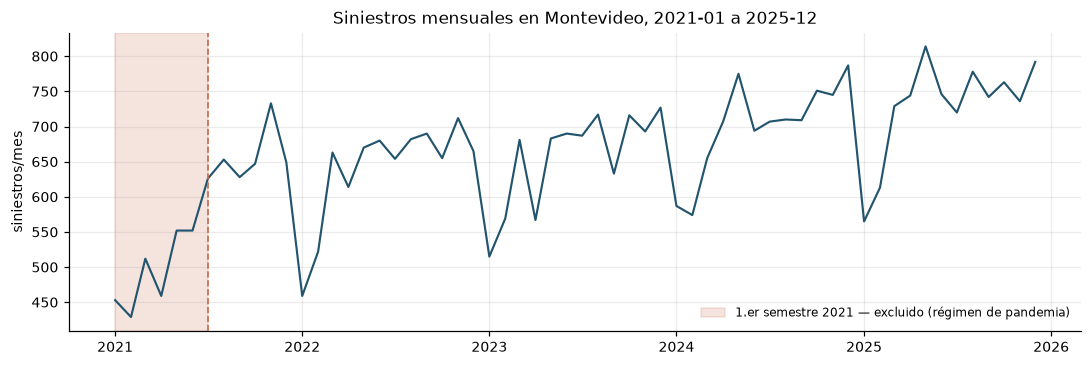

In [17]:
serie_m = completo.set_index("Fecha").resample("MS").size()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(serie_m.index, serie_m.to_numpy(), color="#22546e", linewidth=1.4)
ax.axvspan(pd.Timestamp(FECHA_INICIO_CRUDA), pd.Timestamp(FECHA_INICIO),
           color="#c96a4a", alpha=0.18,
           label=f"1.er semestre {A0} — excluido (régimen de pandemia)")
ax.axvline(pd.Timestamp(FECHA_INICIO), color="#c96a4a", lw=1.1, ls="--")
ax.set_title(f"Siniestros mensuales en {DEPARTAMENTO.title()}, "
             f"{serie_m.index[0]:%Y-%m} a {serie_m.index[-1]:%Y-%m}")
ax.set_ylabel("siniestros/mes")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
guardar_figura(fig, "fig1_cobertura_temporal")
plt.show()


**Los tres pasos coinciden y la decisión queda respaldada.**

El primer semestre de 2021 acumula un déficit grande frente a los mismos meses de los años
siguientes (tabla `12_pandemia_paso1_nivel`). El índice estacional muestra que **no es un efecto
de tendencia**: descontado el nivel de cada año, los meses de febrero a junio de 2021 quedan
varios puntos por debajo de la forma intraanual típica, con el mínimo en abril
(`12b_pandemia_paso2_indice_estacional`). Enero de 2021 es la excepción —su índice coincide con
el de referencia—, lo que es coherente con la cronología sanitaria: la ola grande fue a partir de
marzo. Se lo excluye igual, porque cortar en febrero dejaría un mes suelto y un límite arbitrario;
el costo son unos pocos cientos de registros que la tabla `12e_costo_del_corte` deja explícito.

El tercer paso es el que cierra el argumento: julio–diciembre de 2021 encadena con los años
siguientes dentro de la variación interanual ordinaria de la serie, y su forma intraanual vuelve a
la de referencia (`12c` y `12d`). **El tramo conservado es homogéneo con el resto del período**,
que es exactamente lo que el corte tenía que lograr.

Queda una excepción que conviene declarar en vez de pasarla por alto: **noviembre de 2021 se
aparta hacia arriba** de la forma esperada, tanto en el índice anual como en el del segundo
semestre. El diagnóstico no tiene con qué explicarlo —no hay ninguna variable disponible que lo
justifique— y no lo trata de forma especial: se lo deja en la serie y se lo señala aquí como el
único mes atípico del tramo conservado.

> **Lo que esto no resuelve.** La serie tiene una **tendencia creciente** sostenida a lo largo de
> todo el período conservado. Es un fenómeno real, no un artefacto de la pandemia, y el corte no
> lo elimina ni pretende hacerlo. Tiene una consecuencia directa sobre la evaluación —cualquier
> modelo ajustado sobre el tramo inicial y evaluado sobre el final predice por debajo del nivel
> real— y se cuantifica en la sección 4.3.


### 3.2 Cobertura territorial: los municipios

Montevideo se divide en **ocho municipios** (A, B, C, CH, D, E, F y G), la unidad de
descentralización político-administrativa del departamento. Es la zonificación que adoptó el
proyecto tras la reunión de seguimiento del 2026-09-07, en sustitución de los 62 barrios.

El criterio no es estadístico sino de destinatario: el municipio es la unidad que **tiene un
gobierno propio con competencias en tránsito**, de modo que una predicción por municipio se puede
accionar. La contrapartida —menos zonas y mucho más grandes— se mide en esta sección y en la 4.4.


In [18]:
por_zona = (df_mvd.groupby(ZONA).size().rename("siniestros")
            .sort_values(ascending=False).to_frame())
por_zona["dias_con_siniestro"] = df_mvd.groupby(ZONA)["Fecha"].nunique()
por_zona["pct_dias_con_siniestro"] = (100 * por_zona["dias_con_siniestro"] / len(DIAS)).round(1)
por_zona["pct_del_total"] = (100 * por_zona["siniestros"] / len(df_mvd)).round(2)
por_zona["media_diaria"] = (por_zona["siniestros"] / len(DIAS)).round(3)
guardar_tabla(por_zona.reset_index(), "13_cobertura_municipios")

resumen_terr = pd.DataFrame(
    [("municipios de la capa", len(capa)),
     ("municipios con al menos un siniestro", len(por_zona)),
     ("siniestros — mínimo por municipio", f"{int(por_zona['siniestros'].min()):,}"),
     ("siniestros — mediana por municipio", f"{int(por_zona['siniestros'].median()):,}"),
     ("siniestros — máximo por municipio", f"{int(por_zona['siniestros'].max()):,}"),
     ("razón máximo/mínimo",
      f"{por_zona['siniestros'].max() / por_zona['siniestros'].min():.2f}×"),
     ("% de días con al menos un siniestro — mínimo",
      f"{por_zona['pct_dias_con_siniestro'].min():.1f} %"),
     ("% de días con al menos un siniestro — máximo",
      f"{por_zona['pct_dias_con_siniestro'].max():.1f} %")],
    columns=["indicador", "valor"],
)
guardar_tabla(resumen_terr, "13b_concentracion_territorial")


[tabla]  experiments\diagnostico_datos\tablas\13_cobertura_municipios.csv


,municipio,siniestros,dias_con_siniestro,pct_dias_con_siniestro,pct_del_total,media_diaria
0,MUNICIPIO C,5783,1566,95.2,15.80,3.516
1,MUNICIPIO B,5377,1562,95.0,14.69,3.269
2,MUNICIPIO D,5319,1572,95.6,14.53,3.233
3,MUNICIPIO A,5016,1549,94.2,13.70,3.049
4,MUNICIPIO F,4424,1533,93.2,12.08,2.689
5,MUNICIPIO G,3701,1446,87.9,10.11,2.250
6,MUNICIPIO E,3615,1414,86.0,9.87,2.198
7,MUNICIPIO CH,3377,1386,84.3,9.22,2.053


[tabla]  experiments\diagnostico_datos\tablas\13b_concentracion_territorial.csv


,indicador,valor
0,municipios de la capa,8
1,municipios con al menos un siniestro,8
2,siniestros — mínimo por municipio,"3,377"
3,siniestros — mediana por municipio,"4,720"
4,siniestros — máximo por municipio,"5,783"
5,razón máximo/mínimo,1.71×
6,% de días con al menos un siniestro — mínimo,84.3 %
7,% de días con al menos un siniestro — máximo,95.6 %


[figura] experiments\diagnostico_datos\figuras\fig2_cobertura_territorial.png


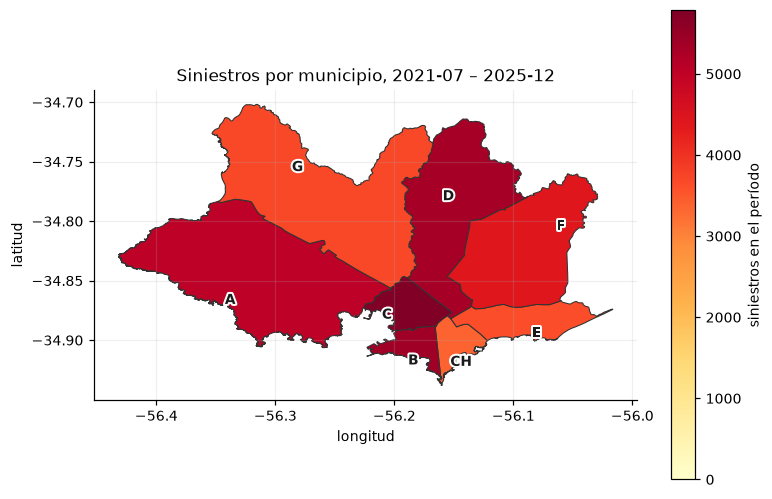

In [19]:
act = por_zona["siniestros"].to_dict()
vmax = max(act.values())
cmap = plt.get_cmap("YlOrRd")

fig, ax = plt.subplots(figsize=(7.2, 5.6))
for nombre, anillos in capa:
    for a in anillos:
        xy = a[:, :2]
        if np.abs(xy[:, 0]).max() > 180:            # viene en UTM: pasar a lon/lat
            lon, lat = A_WGS84.transform(xy[:, 0], xy[:, 1])
            xy = np.column_stack([lon, lat])
        v = act.get(nombre, 0)
        ax.add_patch(PolyPatch(xy, closed=True, facecolor=cmap(v / vmax),
                               edgecolor="#333333", linewidth=0.7))
        if v:                                       # etiqueta en el centroide del anillo mayor
            # halo blanco: sin él la etiqueta se pierde sobre los rellenos más oscuros
            ax.annotate(nombre.replace(PREFIJO_ZONA, ""), xy.mean(axis=0), ha="center",
                        va="center", fontsize=9, fontweight="bold", color="#1a1a1a",
                        path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
ax.autoscale_view()
ax.set_aspect("equal")
ax.set_title(f"Siniestros por municipio, {DIAS[0]:%Y-%m} – {DIAS[-1]:%Y-%m}")
ax.set_xlabel("longitud"); ax.set_ylabel("latitud"); ax.grid(alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
fig.colorbar(sm, ax=ax, label="siniestros en el período", shrink=0.8)
fig.tight_layout()
guardar_figura(fig, "fig2_cobertura_territorial")
plt.show()


Los ocho municipios están representados y **el reparto es notablemente parejo**: entre el más y el
menos activo hay una razón inferior a 2×, y todos registran siniestros en más del 80 % de los días
del período. Con barrios esa razón superaba el orden de magnitud.

Esto tiene dos consecuencias opuestas que conviene no confundir:

- **A favor:** todos los municipios tienen soporte de sobra para estimar una tasa estable, y
  desaparece por completo el problema de las zonas casi vacías que arrastraba la grilla de 1 km.
- **En contra:** si las zonas se parecen tanto entre sí, **queda poco para que un modelo ordene**.
  La sección 4.3 cuantifica cuánto de la variación total explica la identidad del municipio; la
  4.4 discute qué significa esto para el producto.

Una limitación de representatividad que conviene declarar, y que la agregación **no** corrige: el
mapa refleja **dónde se registran** siniestros, no dónde son más probables por unidad de
exposición. Sin datos de tránsito no se puede normalizar por volumen de vehículos, de modo que un
municipio muy transitado aparecerá arriba aunque su riesgo por viaje sea bajo.


### 3.3 Cobertura de la unidad de análisis: el panel día × municipio


In [20]:
ZONAS = sorted(df_mvd[ZONA].unique())
idx = pd.MultiIndex.from_product([DIAS, ZONAS], names=["fecha", ZONA])
y = (df_mvd.groupby(["Fecha", ZONA]).size()
     .reindex(idx, fill_value=0).rename("n_siniestros"))
M = y.to_numpy().reshape(len(DIAS), len(ZONAS))
assert M.sum() == len(df_mvd), "se perdieron siniestros al armar el panel"

no_cero = int((M > 0).sum())
panel_tab = pd.DataFrame(
    [("días del período", f"{len(DIAS):,}"),
     ("municipios", len(ZONAS)),
     ("filas del panel (días × municipios)", f"{M.size:,}"),
     ("filas con al menos un siniestro", f"{no_cero:,}"),
     ("densidad (filas no nulas)", f"{100 * no_cero / M.size:.2f} %"),
     ("ceros", f"{100 * (1 - no_cero / M.size):.2f} %"),
     ("media de siniestros por fila", f"{M.mean():.4f}"),
     ("máximo en una fila", int(M.max()))],
    columns=["indicador", "valor"],
)
guardar_tabla(panel_tab, "14_panel_dia_municipio")


[tabla]  experiments\diagnostico_datos\tablas\14_panel_dia_municipio.csv


,indicador,valor
0,días del período,"1,645"
1,municipios,8
2,filas del panel (días × municipios),"13,160"
3,filas con al menos un siniestro,"12,028"
4,densidad (filas no nulas),91.40 %
5,ceros,8.60 %
6,media de siniestros por fila,2.7821
7,máximo en una fila,13


**Éste es el cambio de fondo respecto de todas las versiones anteriores del diagnóstico.** El
panel pasa de decenas de miles de filas casi vacías a algo más de trece mil filas en su enorme
mayoría **no nulas**: los ceros caen de 95,08 % (grilla de 1 km) y 71,96 % (barrios) a menos del
9 %.

El problema deja de ser «un evento raro en ventanas de un día» y pasa a ser **una regresión de
conteo ordinaria**, con una media cercana a tres siniestros por municipio y día. Dos consecuencias
inmediatas para el diseño del modelado, que el notebook correspondiente debe recoger:

- **No hay exceso de ceros que tratar.** Cualquier variante *zero-inflated* que se hubiera
  considerado con las zonificaciones anteriores queda sin objeto, y **el balanceo no corresponde**
  —no hay clases que balancear—.
- **La interpolación de ceros que se había propuesto pierde sentido.** Se pensó para un panel
  dominado por ceros estructurales; con esta densidad no hay nada que interpolar.


### 3.4 Cobertura de las variables exógenas

In [21]:
fer = holidays.country_holidays("UY", years=range(DIAS[0].year, DIAS[-1].year + 1),
                                categories=CATEGORIAS_FERIADO)
fer_def = holidays.country_holidays("UY", years=range(DIAS[0].year, DIAS[-1].year + 1))

es_feriado = pd.Series(DIAS.date, index=DIAS).map(lambda d: d in fer)
es_finde = pd.Series(DIAS.dayofweek >= 5, index=DIAS)
tipo_dia = pd.Series(np.select([es_feriado, es_finde], ["feriado", "fin_semana"],
                               default="entre_semana"), index=DIAS, name="tipo_dia")

cal = tipo_dia.value_counts().rename_axis("tipo_dia").reset_index(name="días")
cal["pct"] = (100 * cal["días"] / len(DIAS)).round(1)
cal["media_siniestros_dia"] = cal["tipo_dia"].map(
    por_dia.reindex(DIAS).groupby(tipo_dia).mean().round(2))
guardar_tabla(cal, "15_cobertura_calendario")

omitidos = sorted(set(fer) - set(fer_def))
omitidos = [d for d in omitidos if DIAS[0].date() <= d <= DIAS[-1].date()]
guardar_tabla(pd.DataFrame(
    [("feriados con categories=('public','bank')", len([d for d in fer if DIAS[0].date() <= d <= DIAS[-1].date()])),
     ("feriados con la configuración por defecto", len([d for d in fer_def if DIAS[0].date() <= d <= DIAS[-1].date()])),
     ("días que la configuración por defecto omite", len(omitidos))],
    columns=["configuración de `holidays`", "días en el período"]), "16_feriados")

if omitidos:
    guardar_tabla(pd.DataFrame({"fecha": [str(d) for d in omitidos],
                                "nombre": [fer[d] for d in omitidos]}).head(40),
                  "16b_feriados_omitidos_por_defecto")

[tabla]  experiments\diagnostico_datos\tablas\15_cobertura_calendario.csv


,tipo_dia,días,pct,media_siniestros_dia
0,entre_semana,1114,67.7,24.33
1,fin_semana,454,27.6,18.31
2,feriado,77,4.7,15.64


[tabla]  experiments\diagnostico_datos\tablas\16_feriados.csv


,configuración de `holidays`,días en el período
0,"feriados con categories=('public','bank')",77
1,feriados con la configuración por defecto,23
2,días que la configuración por defecto omite,54


[tabla]  experiments\diagnostico_datos\tablas\16b_feriados_omitidos_por_defecto.csv


,fecha,nombre
0,2021-10-11,Día de la Diversidad Cultural
1,2021-11-02,Día de los Difuntos
2,2022-01-06,Día de los Niños
3,2022-02-28,Carnaval
4,2022-03-01,Carnaval
5,2022-04-11,Semana de Turismo
6,2022-04-12,Semana de Turismo
7,2022-04-13,Semana de Turismo
8,2022-04-14,Semana de Turismo
9,2022-04-15,Semana de Turismo


**El calendario está cubierto y el problema que este diagnóstico detectó en su versión nacional
sigue resuelto.** La configuración por omisión de `holidays` para Uruguay omite Carnaval y Semana
de Turismo —los dos períodos de mayor alteración de la movilidad del año—; el ETL vigente usa
`categories=("public", "bank")`, que sí los incluye. La tabla `16_feriados` deja la diferencia a
la vista.

La media de siniestros por tipo de día muestra que la variable **discrimina con claridad**: los
feriados y los fines de semana no se comportan como los días hábiles. Con la unidad de análisis
agregada a ocho municipios, el peso de esta variable es bastante mayor que el que tenía a nivel de
barrio, y las secciones 4.2 y 4.3 lo cuantifican.

**El clima está integrado** (sección 2.7), lo que cierra el otro hueco que el diagnóstico
nacional reportaba como abierto.


## 4. Adecuación

### 4.1 La variable objetivo

In [22]:
vals, cuentas = np.unique(M, return_counts=True)
dist = pd.DataFrame({"n_siniestros": vals, "filas": cuentas})
dist["pct"] = (100 * dist["filas"] / M.size).round(3)
guardar_tabla(dist, "17_distribucion_objetivo")

media, var = M.mean(), M.var()
disp = pd.DataFrame(
    [("media", round(float(media), 4)),
     ("varianza", round(float(var), 4)),
     ("índice de dispersión (var/media)", round(float(var / media), 3)),
     ("máximo", int(M.max())),
     ("% de filas en cero", f"{100 * (M == 0).mean():.2f} %"),
     ("% de filas con 1", f"{100 * (M == 1).mean():.2f} %"),
     ("% de filas con 2 o más", f"{100 * (M >= 2).mean():.2f} %")],
    columns=["indicador", "valor"],
)
guardar_tabla(disp, "18_dispersion_objetivo")

[tabla]  experiments\diagnostico_datos\tablas\17_distribucion_objetivo.csv


,n_siniestros,filas,pct
0,0,1132,8.602
1,1,2430,18.465
2,2,2969,22.561
3,3,2530,19.225
4,4,1829,13.898
5,5,1177,8.944
6,6,573,4.354
7,7,289,2.196
8,8,141,1.071
9,9,60,0.456


[tabla]  experiments\diagnostico_datos\tablas\18_dispersion_objetivo.csv


,indicador,valor
0,media,2.7821
1,varianza,3.5039
2,índice de dispersión (var/media),1.259
3,máximo,13
4,% de filas en cero,8.60 %
5,% de filas con 1,18.47 %
6,% de filas con 2 o más,72.93 %


El objetivo es un **conteo con sobredispersión leve**: la varianza supera a la media en algo más
de un 25 %, de modo que un Poisson puro queda algo justo pero sigue siendo la familia de
referencia, y una alternativa binomial negativa es la primera extensión razonable a probar.

La consecuencia para el protocolo de evaluación se mantiene respecto de versiones anteriores: las
métricas deben medir **calibración y ordenamiento** de una intensidad esperada. La recomendación
—que el notebook de modelado debe implementar— es **desvianza de Poisson** como métrica principal.

Lo que **sí cambia** es el argumento por el que se descarta el error absoluto medio. Antes se lo
descartaba porque premiaba predecir siempre cerca de cero; con esta zonificación el objetivo ya no
está concentrado en cero y ese argumento no aplica. Se lo sigue prefiriendo por una razón
distinta: el MAE trata igual un error de una unidad sobre un valor esperado de 0,5 que sobre uno
de 5, mientras que la desvianza lo pondera por el nivel, que es lo que corresponde a un conteo.


### 4.2 ¿Cuánta señal temporal hay realmente?

Es la pregunta que más condiciona el modelado. **Se recalcula íntegramente sobre los municipios**,
porque una conclusión obtenida con otra granularidad no se hereda: al agregar barrios en
municipios sube mucho el volumen por zona y la señal puede aparecer donde antes quedaba sepultada
bajo el ruido de Poisson.

El contraste correcto no es contra cero, sino contra lo que produciría el **puro azar**: se
simulan series de Poisson con la misma tasa media de cada municipio y se compara la
autocorrelación observada contra la banda que generan esas simulaciones.

Se agrega aquí un paso que las versiones anteriores no tenían y que resulta decisivo: la misma
medición **sobre el residuo**, después de descontar día de la semana y feriado. Sirve para separar
dos cosas que la autocorrelación cruda confunde — la persistencia genuina de la serie y el simple
hecho de que el calendario se repite cada siete días.


In [23]:
def acf(x, k):
    x = np.asarray(x, float) - np.mean(x)
    den = float((x * x).sum())
    return float((x[:-k] * x[k:]).sum() / den) if den > 0 else np.nan


N_SIM = 400          # simulaciones por municipio para estimar la banda nula
ACF_POR_REZAGO = {}  # se reutiliza en la figura, para no simular dos veces

# Residuo: se le quita a cada serie la media de su celda (día de la semana × feriado)
clave_cal = pd.factorize(
    pd.MultiIndex.from_arrays([DIAS.dayofweek, es_feriado.to_numpy()]))[0]
RESIDUOS = np.column_stack([
    M[:, j] - pd.Series(M[:, j], dtype=float).groupby(clave_cal).transform("mean").to_numpy()
    for j in range(M.shape[1])])

filas = []
for k in (1, 7):
    obs = np.array([acf(M[:, j], k) for j in range(M.shape[1])])
    res = np.array([acf(RESIDUOS[:, j], k) for j in range(M.shape[1])])
    banda = np.array([
        np.nanpercentile([acf(rng.poisson(M[:, j].mean(), M.shape[0]), k)
                          for _ in range(N_SIM)], 97.5)
        for j in range(M.shape[1])])
    ACF_POR_REZAGO[k] = (obs, res, banda)
    filas.append((k, round(float(np.nanmedian(obs)), 4), round(float(np.nanmax(obs)), 4),
                  int((obs > banda).sum()),
                  round(float(np.nanmedian(res)), 4), int((res > banda).sum()),
                  round(float(np.nanmean(banda)), 4), round(0.025 * M.shape[1], 1)))

senal = pd.DataFrame(filas, columns=[
    "rezago", "ACF cruda — mediana", "ACF cruda — máxima", "municipios sobre la banda (cruda)",
    "ACF del residuo — mediana", "municipios sobre la banda (residuo)",
    "banda nula Poisson (p97,5 media)", "municipios esperables por azar"])
guardar_tabla(senal, "19_senal_temporal_municipios")


[tabla]  experiments\diagnostico_datos\tablas\19_senal_temporal_municipios.csv


,rezago,ACF cruda — mediana,ACF cruda — máxima,municipios sobre la banda (cruda),ACF del residuo — mediana,municipios sobre la banda (residuo),"banda nula Poisson (p97,5 media)",municipios esperables por azar
0,1,0.0558,0.0791,5,0.0475,5,0.0464,0.2
1,7,0.0569,0.0849,5,0.0079,0,0.0450,0.2


In [24]:
serie_dep = M.sum(axis=1).astype(float)
res_cal = serie_dep - pd.Series(serie_dep, index=DIAS).groupby(tipo_dia).transform("mean").to_numpy()

agregada = pd.DataFrame(
    [("serie cruda del departamento", round(acf(serie_dep, 1), 4), round(acf(serie_dep, 7), 4)),
     ("residuo tras descontar tipo_dia", round(acf(res_cal, 1), 4), round(acf(res_cal, 7), 4))],
    columns=["serie", "ACF rezago 1", "ACF rezago 7"],
)
guardar_tabla(agregada, "20_senal_serie_agregada")

# Varianza de la serie diaria del departamento explicada por bloques de calendario
sd = pd.DataFrame({"y": serie_dep}, index=DIAS)
sd["tipo_dia"] = tipo_dia
sd["mes"] = DIAS.month
sd["dow"] = DIAS.dayofweek
sstot = float(((sd["y"] - sd["y"].mean()) ** 2).sum())
filas = []
for nombre, cols in [("tipo_dia", ["tipo_dia"]), ("día de la semana", ["dow"]),
                     ("mes", ["mes"]), ("tipo_dia + mes", ["tipo_dia", "mes"]),
                     ("día de la semana + mes", ["dow", "mes"])]:
    pred = sd.groupby(cols)["y"].transform("mean")
    filas.append((nombre, round(100 * (1 - float(((sd["y"] - pred) ** 2).sum()) / sstot), 1)))
guardar_tabla(pd.DataFrame(filas, columns=["bloque de calendario", "% de varianza explicada"]),
              "20b_varianza_calendario")

guardar_tabla(sd.groupby("dow")["y"].mean().round(2).rename("media diaria")
              .rename_axis("día de la semana (0 = lunes)").reset_index(), "20c_perfil_semanal")


[tabla]  experiments\diagnostico_datos\tablas\20_senal_serie_agregada.csv


,serie,ACF rezago 1,ACF rezago 7
0,serie cruda del departamento,0.1977,0.2964
1,residuo tras descontar tipo_dia,0.1948,0.1825


[tabla]  experiments\diagnostico_datos\tablas\20b_varianza_calendario.csv


,bloque de calendario,% de varianza explicada
0,tipo_dia,22.3
1,día de la semana,20.8
2,mes,7.4
3,tipo_dia + mes,30.9
4,día de la semana + mes,30.9


[tabla]  experiments\diagnostico_datos\tablas\20c_perfil_semanal.csv


,día de la semana (0 = lunes),media diaria
0,0,23.14
1,1,23.48
2,2,23.57
3,3,23.55
4,4,25.74
5,5,20.25
6,6,16.06


[figura] experiments\diagnostico_datos\figuras\fig3_senal_temporal.png


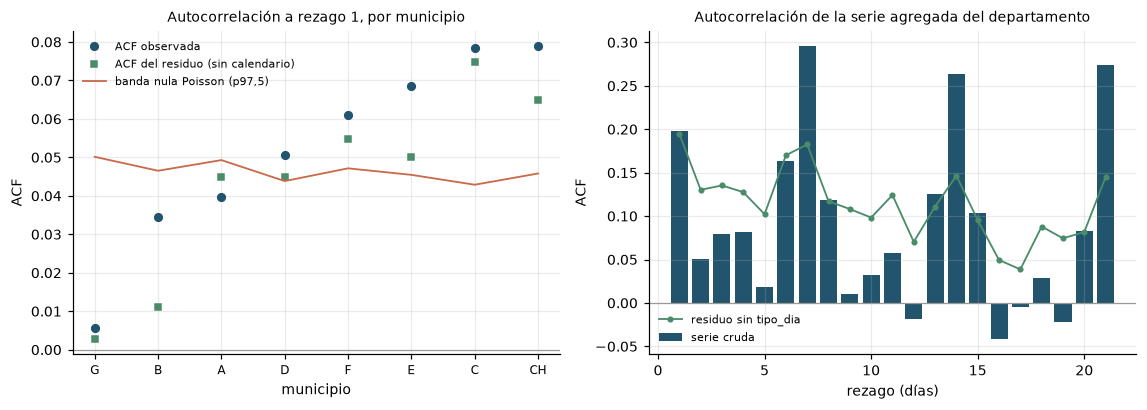

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

k = 1
obs, res, banda = ACF_POR_REZAGO[k]        # calculados en la celda anterior
orden = np.argsort(obs)
ax1.plot(obs[orden], "o", ms=5, color="#22546e", label="ACF observada")
ax1.plot(res[orden], "s", ms=4, color="#4a8c6a", label="ACF del residuo (sin calendario)")
ax1.plot(banda[orden], "-", color="#c96a4a", lw=1.2, label="banda nula Poisson (p97,5)")
ax1.axhline(0, color="#999999", lw=0.8)
ax1.set_xticks(range(len(orden)))
ax1.set_xticklabels([ZONAS[i].replace(PREFIJO_ZONA, "") for i in orden], fontsize=8)
ax1.set_title(f"Autocorrelación a rezago {k}, por municipio", fontsize=9)
ax1.set_xlabel("municipio"); ax1.set_ylabel("ACF")
ax1.legend(frameon=False, fontsize=7.5)

lags = np.arange(1, 22)
ax2.bar(lags, [acf(serie_dep, l) for l in lags], color="#22546e", label="serie cruda")
ax2.plot(lags, [acf(res_cal, l) for l in lags], "o-", ms=3, color="#4a8c6a", lw=1.2,
         label="residuo sin tipo_dia")
ax2.axhline(0, color="#999999", lw=0.8)
ax2.set_title("Autocorrelación de la serie agregada del departamento", fontsize=9)
ax2.set_xlabel("rezago (días)"); ax2.set_ylabel("ACF")
ax2.legend(frameon=False, fontsize=7.5)

fig.tight_layout()
guardar_figura(fig, "fig3_senal_temporal")
plt.show()


**La conclusión se invierte respecto de las versiones anteriores, y hay que decirlo sin
atenuantes.** Con celdas de 1 km y con barrios, la autocorrelación por zona caía por debajo de la
banda nula y el diagnóstico concluía que *no se detecta señal temporal de corto plazo*. Con
municipios **sí se detecta**: la mediana de la ACF a rezago 1 supera la banda nula de Poisson, y
lo hace en la mayoría de los municipios, muy por encima de lo esperable por azar.

La explicación no es que el fenómeno haya cambiado, sino que **antes el ruido de Poisson lo
tapaba**. Una serie con media 0,35 siniestros/día tiene una relación señal-ruido demasiado baja
para detectar una autocorrelación de 0,05; una con media 2,8 no.

El desglose por rezago es la parte útil, y es lo que aporta la medición sobre el residuo:

- **A rezago 7 la señal es enteramente de calendario.** Descontado el día de la semana y el
  feriado, *ningún* municipio queda por encima de la banda nula. El pico semanal de la serie
  agregada —bien visible en la figura— es la repetición del calendario, no memoria del proceso.
- **A rezago 1 queda persistencia genuina.** El residuo conserva autocorrelación por encima de la
  banda en la mayoría de los municipios. Hay algo real de un día para el otro que el calendario no
  explica.

**Consecuencia de modelado, con su matiz.** A diferencia de las versiones anteriores, un rezago de
un día **no queda descartado de entrada**: hay evidencia de que aporta algo. Pero la magnitud es
pequeña —una ACF del orden de 0,05 explica menos del 1 % de la varianza de esa serie—, así que no
puede ser el eje del modelo. La línea base defendible sigue siendo **tasa histórica del municipio
× factor de calendario**, y el rezago de un día entra como candidato a evaluar contra ella, no
como supuesto.


### 4.3 ¿Qué puede aportar cada bloque de variables?

Antes de construir modelos conviene saber cuánto hay para ganar con cada familia de variables. La
medición se hace en **dos pasadas**, y la distinción entre ambas es el aporte metodológico de esta
versión del diagnóstico.

**Primera pasada — techos en muestra.** Se compara la **desvianza de Poisson** de varios
predictores construidos como *oráculos*: a cada uno se le entrega directamente la media empírica
del grupo correspondiente, calculada sobre los mismos datos con los que se lo evalúa. Cada valor
es una **cota superior**: ningún modelo real que use sólo esa información la va a superar.

**Segunda pasada — desempeño fuera de muestra.** El problema de la primera es que un bloque con
muchos grupos y pocos días por grupo memoriza el ruido y exhibe una mejora que no existe. Para
medirlo honestamente se parte el panel por la mitad **en el tiempo**, se estiman las medias de
grupo con la primera mitad y se evalúa la desvianza sobre la segunda. Es una versión mínima del
protocolo de evaluación, hecha aquí sólo para dimensionar el aporte de cada bloque; **la
partición definitiva se fija en el notebook de modelado**, y el conjunto de prueba real no se toca
en este diagnóstico.


In [26]:
def desvianza(y_obs, mu):
    mu = np.clip(np.asarray(mu, float), 1e-12, None)
    y_obs = np.asarray(y_obs, float)
    pos = y_obs > 0
    t = np.zeros_like(y_obs)
    t[pos] = y_obs[pos] * np.log(y_obs[pos] / mu[pos])
    return float(2 * np.sum(t - (y_obs - mu)) / y_obs.size)


# ── Primera pasada: techos en muestra (oráculos) ──
plano = M.ravel().astype(float)
g = plano.mean()
media_dia = np.repeat(M.mean(axis=1), M.shape[1])          # varía por día, igual en todo municipio
media_zona = np.tile(M.mean(axis=0), M.shape[0])           # varía por municipio, igual todo el año

d0 = desvianza(plano, np.full_like(plano, g))
filas = []
for nombre, mu in [
    ("constante global (sin información)", np.full_like(plano, g)),
    ("oráculo de día — techo de TODA variable de día", media_dia),
    ("oráculo de municipio — tasa histórica", media_zona),
    ("municipio × día", media_zona * (media_dia / g)),
]:
    d = desvianza(plano, mu)
    filas.append((nombre, round(d, 5), f"{100 * (d / d0 - 1):+.1f} %"))
guardar_tabla(pd.DataFrame(filas, columns=["información disponible", "desvianza de Poisson",
                                           "mejora sobre la constante"]),
              "21_aporte_bloques_en_muestra")

vt = plano.var()
guardar_tabla(pd.DataFrame(
    [("varianza total del objetivo", round(float(vt), 5), "100,0 %"),
     ("entre municipios (varianza de las medias por municipio)",
      round(float(M.mean(axis=0).var()), 5), f"{100 * M.mean(axis=0).var() / vt:.1f} %"),
     ("entre días (varianza de las medias por día)",
      round(float(M.mean(axis=1).var()), 5), f"{100 * M.mean(axis=1).var() / vt:.2f} %")],
    columns=["componente", "varianza", "% de la total"]), "21b_descomposicion_varianza")


[tabla]  experiments\diagnostico_datos\tablas\21_aporte_bloques_en_muestra.csv


,información disponible,desvianza de Poisson,mejora sobre la constante
0,constante global (sin información),1.36899,+0.0 %
1,oráculo de día — techo de TODA variable de día,1.13018,-17.4 %
2,oráculo de municipio — tasa histórica,1.26796,-7.4 %
3,municipio × día,1.02914,-24.8 %


[tabla]  experiments\diagnostico_datos\tablas\21b_descomposicion_varianza.csv


,componente,varianza,% de la total
0,varianza total del objetivo,3.50387,"100,0 %"
1,entre municipios (varianza de las medias por m...,0.27688,7.9 %
2,entre días (varianza de las medias por día),0.64728,18.47 %


In [27]:
# ── Segunda pasada: desempeño fuera de muestra, con partición temporal por la mitad ──
CORTE = len(DIAS) // 2
tr, ev = slice(0, CORTE), slice(CORTE, len(DIAS))
Y_ev = M[ev].ravel().astype(float)
nz = M.shape[1]

g_tr = M[tr].mean()
tasa_zona = M[tr].mean(axis=0)                                     # 8 parámetros
serie_tr = pd.Series(M[tr].mean(axis=1))

dow = DIAS.dayofweek.to_numpy()
fer_np = es_feriado.to_numpy()
llovio = None
if clima is not None and "precipitacion_mm" in clima.columns:
    lluvia = (clima.set_index("fecha")["precipitacion_mm"].reindex(DIAS) > 0.1)
    llovio = lluvia.fillna(False).astype(int).to_numpy()


def factor(claves):
    """Factor multiplicativo de día, estimado sólo con la primera mitad."""
    k = pd.factorize(pd.MultiIndex.from_arrays(list(claves)))[0]
    f = serie_tr.groupby(k[tr]).mean() / g_tr
    return pd.Series(k).map(f).fillna(1.0).to_numpy(), int(pd.Series(k[tr]).nunique())


def saturado(claves):
    """Media de celda municipio × claves, estimada sólo con la primera mitad."""
    k = pd.factorize(pd.MultiIndex.from_arrays(list(claves)))[0]
    kf = np.repeat(k, nz) * nz + np.tile(np.arange(nz), len(DIAS))
    m = pd.DataFrame({"k": kf, "y": M.ravel().astype(float)})
    medias = m.iloc[:CORTE * nz].groupby("k")["y"].mean()
    return m["k"].map(medias).fillna(g_tr).to_numpy(), int(pd.Series(kf[:CORTE * nz]).nunique())


f_cal, n_cal = factor([dow, fer_np])
modelos = [
    ("constante global", 1, np.full_like(Y_ev, g_tr)),
    ("sólo factor de calendario (día de la semana + feriado)", n_cal,
     np.repeat(g_tr * f_cal[ev], nz)),
    ("sólo tasa histórica del municipio", nz, np.tile(tasa_zona, len(DIAS) - CORTE)),
    ("tasa del municipio × factor de calendario  ← línea base propuesta", nz + n_cal,
     np.tile(tasa_zona, len(DIAS) - CORTE) * np.repeat(f_cal[ev], nz)),
]
if llovio is not None:
    f_ll, n_ll = factor([dow, fer_np, llovio])
    modelos.append(("tasa del municipio × (calendario + llovió)", nz + n_ll,
                    np.tile(tasa_zona, len(DIAS) - CORTE) * np.repeat(f_ll[ev], nz)))
mu_sat, n_sat = saturado([dow, fer_np, DIAS.month.to_numpy()])
modelos.append(("celdas saturadas municipio × calendario × mes (sin regularizar)", n_sat,
                mu_sat[CORTE * nz:]))

d0_ev = desvianza(Y_ev, np.full_like(Y_ev, g_tr))
filas = [(nom, par, round(desvianza(Y_ev, mu), 5),
          f"{100 * (desvianza(Y_ev, mu) / d0_ev - 1):+.1f} %") for nom, par, mu in modelos]
guardar_tabla(pd.DataFrame(filas, columns=[
    "predictor (estimado sólo con la 1.ª mitad)", "medias estimadas",
    "desvianza de Poisson en la 2.ª mitad", "mejora sobre la constante"]),
    "21c_aporte_bloques_fuera_de_muestra")

guardar_tabla(pd.DataFrame(
    [("media del objetivo en la 1.ª mitad", round(float(M[tr].mean()), 4)),
     ("media del objetivo en la 2.ª mitad", round(float(M[ev].mean()), 4)),
     ("deriva entre mitades", f"{100 * (M[ev].mean() / M[tr].mean() - 1):+.1f} %")],
    columns=["indicador", "valor"]), "21d_deriva_entre_mitades")


[tabla]  experiments\diagnostico_datos\tablas\21c_aporte_bloques_fuera_de_muestra.csv


,predictor (estimado sólo con la 1.ª mitad),medias estimadas,desvianza de Poisson en la 2.ª mitad,mejora sobre la constante
0,constante global,1,1.36394,+0.0 %
1,sólo factor de calendario (día de la semana + ...,14,1.30530,-4.3 %
2,sólo tasa histórica del municipio,8,1.26172,-7.5 %
3,tasa del municipio × factor de calendario ← l...,22,1.20308,-11.8 %
4,tasa del municipio × (calendario + llovió),34,1.20716,-11.5 %
5,celdas saturadas municipio × calendario × mes ...,888,1.50546,+10.4 %


[tabla]  experiments\diagnostico_datos\tablas\21d_deriva_entre_mitades.csv


,indicador,valor
0,media del objetivo en la 1.ª mitad,2.6369
1,media del objetivo en la 2.ª mitad,2.9271
2,deriva entre mitades,+11.0 %


Las dos pasadas dicen cosas distintas, y la segunda es la que hay que citar en el informe.

**En muestra, el oráculo de día parece dominar.** Su mejora sobre la constante multiplica varias
veces a la del municipio, y eso invita a concluir que las variables exógenas son lo importante.
**Es un espejismo, y por partida doble.** Primero, ese oráculo recibe la media exacta de cada día,
que incluye toda la fluctuación diaria irrepetible: es el techo de *cualquier* variable de día,
incluidas las que nadie tiene. Segundo, en muestra no paga ningún costo por el número de grupos
que usa.

**Fuera de muestra el orden se invierte y aparece el resultado útil**
(`21c_aporte_bloques_fuera_de_muestra`):

- La **tasa histórica del municipio**, con ocho parámetros, mejora sobre la constante bastante más
  que el calendario realizable con catorce.
- El **calendario efectivamente construible** (día de la semana + feriado) rinde mucho menos que
  lo que prometía el oráculo de día. La diferencia entre ambas cifras es la parte de la variación
  diaria que **ninguna variable disponible captura**.
- La combinación **multiplicativa** —tasa del municipio × factor de calendario— supera a los dos
  bloques por separado y es la mejor de la tabla. Es exactamente la línea base que el diagnóstico
  viene recomendando, y ahora está medida en lugar de postulada.
- **Agregar el clima no mejora nada**: la variante con lluvia queda al mismo nivel o levemente por
  debajo. A resolución diaria y con esta agregación espacial, el clima no aporta señal utilizable.
- Las **celdas saturadas** (municipio × calendario × mes, estimadas como medias de celda sin
  regularizar) rinden **peor que no usar nada**. Es el resultado que justifica la forma
  multiplicativa: con este volumen de datos, cruzar municipio y calendario en celdas independientes
  memoriza ruido.

**Dos advertencias sobre cómo leer estos números.**

La descomposición de varianza (`21b`) atribuye a la variación *entre días* un porcentaje mayor que
a la variación *entre municipios*. No contradice lo anterior: buena parte de esa variación diaria
es ruido de Poisson compartido, no señal predecible, y por eso el calendario realizable recupera
sólo una fracción pequeña.

La tabla `21d_deriva_entre_mitades` muestra que el objetivo **crece** entre la primera y la segunda
mitad del período. Todos los predictores de la tabla anterior están estimados sobre el tramo bajo y
evaluados sobre el alto, de modo que **todos** subestiman el nivel y todas las mejoras informadas
son conservadoras. El modelado tendrá que tratar esa tendencia explícitamente —recalibrar el nivel,
incluir tendencia, o ponderar los datos recientes—, y este diagnóstico no decide cuál.


### 4.4 Adecuación al objetivo del producto


In [28]:
adecuacion = pd.DataFrame(
    [("¿Se puede predecir el conteo diario por municipio?", "Sí",
      "el panel es denso (menos del 9 % de ceros) y el objetivo es un conteo de tipo Poisson"),
     ("¿Se puede predecir dónde ocurrirá el próximo siniestro?", "No",
      "la unidad es el municipio-día; la persistencia detectada (4.2) es de magnitud despreciable"),
     ("¿Se puede ordenar municipios por riesgo esperado?", "Sí, con margen estrecho",
      "la tasa por municipio es estable y es el bloque más útil (4.3), pero entre el mayor y el "
      "menor hay menos de 2× (3.2): el ordenamiento es fino y poco robusto"),
     ("¿Se puede estimar riesgo por unidad de exposición?", "No",
      "no hay datos de tránsito: sólo se observa el conteo, no la exposición"),
     ("¿Se puede modelar por gravedad o franja horaria?", "No con el conjunto vigente",
      "el ETL descarta esas columnas; exige volver a ejecutarlo"),
     ("¿Se puede evaluar en municipios no vistos al entrenar?", "Muy limitado",
      "con 8 zonas, reservar 2 deja 6 para entrenar y una medición con enorme error de muestreo"),
     ("¿La resolución espacial sirve para asignar recursos?", "Parcialmente",
      "un municipio abarca entre 1.148 y 14.380 ha: orienta el reparto entre gobiernos "
      "municipales, no el despliegue en calle")],
    columns=["pregunta", "respuesta", "fundamento"],
)
guardar_tabla(adecuacion, "22_adecuacion_objetivo")


[tabla]  experiments\diagnostico_datos\tablas\22_adecuacion_objetivo.csv


,pregunta,respuesta,fundamento
0,¿Se puede predecir el conteo diario por munici...,Sí,el panel es denso (menos del 9 % de ceros) y e...
1,¿Se puede predecir dónde ocurrirá el próximo s...,No,la unidad es el municipio-día; la persistencia...
2,¿Se puede ordenar municipios por riesgo esperado?,"Sí, con margen estrecho",la tasa por municipio es estable y es el bloqu...
3,¿Se puede estimar riesgo por unidad de exposic...,No,no hay datos de tránsito: sólo se observa el c...
4,¿Se puede modelar por gravedad o franja horaria?,No con el conjunto vigente,el ETL descarta esas columnas; exige volver a ...
5,¿Se puede evaluar en municipios no vistos al e...,Muy limitado,"con 8 zonas, reservar 2 deja 6 para entrenar y..."
6,¿La resolución espacial sirve para asignar rec...,Parcialmente,un municipio abarca entre 1.148 y 14.380 ha: o...


Las filas segunda, cuarta y séptima son las que acotan honestamente el alcance del producto. El
sistema puede **estimar y calibrar el conteo esperado por municipio y día**, que sirve para
repartir esfuerzo entre los ocho gobiernos municipales; no puede **anticipar siniestros
individuales**, no puede hablar de **peligrosidad** sin datos de exposición, y no baja a una
resolución operativa de calle. Presentarlo de otro modo ante el tribunal sería insostenible.

**Dos consecuencias del cambio de zonificación que el equipo tiene que asumir explícitamente.**

La primera es que **el experimento del «megamodelo» evaluado en zonas no vistas queda muy
debilitado**. Con 62 barrios era una prueba razonable; con 8 municipios, reservar dos deja seis
para entrenar, y el resultado dependería casi por completo de *cuáles* dos se reserven. Se puede
hacer —dejando *uno* afuera por vez y promediando las ocho corridas, que es lo único defendible a
esta escala—, pero conviene decir de antemano que su poder estadístico es bajo y no puede ser la
evidencia principal de la generalización.

La segunda es que **el margen para ordenar zonas se estrechó**. Con una razón inferior a 2× entre
el municipio más y el menos activo, un modelo que ordene municipios acierta poco más que el orden
de la tasa histórica, y las diferencias entre posiciones contiguas serán menores que el error de
estimación. Es una limitación del alcance elegido, no del método, y el informe debe declararla en
lugar de presentar el ordenamiento como un resultado sólido.


## 5. Coherencia con el conjunto de modelado

El diagnóstico reconstruyó el panel desde las fuentes crudas, de forma independiente del ETL. Si
`data/processed/` está construido **con la misma zonificación y el mismo período**, comparar ambas
reconstrucciones es una verificación cruzada real: una discrepancia significa que uno de los dos
notebooks tiene un error.

Mientras el ETL siga en la configuración anterior (barrios, desde enero de 2021), la comparación
no procede: no habría error que detectar, sino dos alcances distintos. La celda lo distingue en
lugar de informar una discrepancia falsa.


In [29]:
def leer_panel_etl(ruta):
    """El ETL ha exportado con distintos separadores y formatos de fecha según la corrida:
    se detectan en lugar de suponerlos, para que la verificación no falle por eso.

    El formato de fecha se decide mirando el texto, no con `dayfirst`: sobre una fecha ISO
    como 2021-07-01 el modo mixto con dayfirst la lee como el 7 de enero, en silencio. Es
    exactamente el error que la sección 2.3 verifica en la fuente cruda.
    """
    etl = pd.read_csv(ruta, sep=None, engine="python")
    etl.columns = [c.strip() for c in etl.columns]
    fecha = etl["fecha"].astype(str).str.strip()
    if fecha.str.match(r"^\d{4}-\d{2}-\d{2}").all():
        etl["fecha"] = pd.to_datetime(fecha, format="%Y-%m-%d")
    else:                                   # corridas viejas exportaban %d/%m/%Y
        etl["fecha"] = pd.to_datetime(fecha, format="%d/%m/%Y")
    return etl


RUTA_PANEL = DIR_PROC / "panel_diario_montevideo.csv"
if not RUTA_PANEL.exists():
    print("data/processed/ no está construido: se omite la verificación cruzada.")
    print("Ejecutá preparacion_montevideo.ipynb y volvé a correr esta celda.")
else:
    etl = leer_panel_etl(RUTA_PANEL)
    mismo_alcance = (etl["zona_id"].nunique() == len(ZONAS)
                     and etl["fecha"].min() == pd.Timestamp(FECHA_INICIO))
    if not mismo_alcance:
        print("⚠️  El ETL de data/processed/ está en OTRO alcance: no se compara.")
        guardar_tabla(pd.DataFrame(
            [("zonas", len(ZONAS), etl["zona_id"].nunique()),
             ("primer día", f"{DIAS[0]:%Y-%m-%d}", f"{etl['fecha'].min():%Y-%m-%d}"),
             ("último día", f"{DIAS[-1]:%Y-%m-%d}", f"{etl['fecha'].max():%Y-%m-%d}"),
             ("filas", f"{M.size:,}", f"{len(etl):,}")],
            columns=["dimensión", "diagnóstico (municipios)", "ETL (data/processed)"]),
            "23_coherencia_etl_pendiente")
        print("\n   Hay que reejecutar preparacion_montevideo.ipynb con municipios y "
              f"FECHA_INICIO = {FECHA_INICIO!r}.\n   Hasta entonces, NO citar en el informe "
              "ninguna cifra de data/processed/.")
    else:
        comp = pd.DataFrame(
            [("filas del panel", f"{M.size:,}", f"{len(etl):,}",
              "coincide" if M.size == len(etl) else "DISCREPANCIA"),
             ("siniestros totales", f"{int(M.sum()):,}", f"{int(etl['n_siniestros'].sum()):,}",
              "coincide" if int(M.sum()) == int(etl["n_siniestros"].sum()) else "DISCREPANCIA"),
             ("zonas", f"{len(ZONAS):,}", f"{etl['zona_id'].nunique():,}",
              "coincide" if len(ZONAS) == etl["zona_id"].nunique() else "DISCREPANCIA"),
             ("días", f"{len(DIAS):,}", f"{etl['fecha'].nunique():,}",
              "coincide" if len(DIAS) == etl["fecha"].nunique() else "DISCREPANCIA"),
             ("máximo del objetivo", int(M.max()), int(etl["n_siniestros"].max()),
              "coincide" if int(M.max()) == int(etl["n_siniestros"].max()) else "DISCREPANCIA")],
            columns=["comprobación", "diagnóstico (recalculado)", "ETL (data/processed)", "resultado"],
        )
        guardar_tabla(comp, "23_coherencia_etl")
        if (comp["resultado"] == "DISCREPANCIA").any():
            print("\n⚠️  Hay discrepancias: uno de los dos notebooks está mal. Revisar antes de "
                  "citar cualquier cifra en el informe.")


[tabla]  experiments\diagnostico_datos\tablas\23_coherencia_etl.csv


,comprobación,diagnóstico (recalculado),ETL (data/processed),resultado
0,filas del panel,"13,160","13,160",coincide
1,siniestros totales,"36,612","36,612",coincide
2,zonas,8,8,coincide
3,días,"1,645","1,645",coincide
4,máximo del objetivo,13,13,coincide


## 6. Limitaciones y riesgos

Cada fila remite a la sección que la sustenta. La última no tiene sección porque **no es medible
con estos datos**, y decirlo es parte del diagnóstico.

In [30]:
limitaciones = pd.DataFrame(
    [
        ("Tendencia creciente en todo el período", "3.1, 4.3",
         "El objetivo crece de forma sostenida. Un modelo ajustado sobre el tramo inicial "
         "subestima el nivel del tramo final; no lo corrige el corte de 2021.",
         "Tratarla explícitamente en el modelado: recalibrar nivel, tendencia o ponderación."),
        ("Sólo 8 zonas, y muy parecidas entre sí", "3.2, 4.4",
         "Razón menor a 2× entre el municipio mayor y el menor. El margen para ordenar zonas es "
         "estrecho y el hold-out de zonas pierde casi todo su poder.",
         "Declarar el margen; si se evalúa en zonas no vistas, dejar una afuera por vez."),
        ("Resolución espacial gruesa", "2.6, 4.4",
         "Un municipio abarca entre 1.148 y 14.380 ha. El producto orienta el reparto entre "
         "gobiernos municipales, no el despliegue en calle.",
         "Acotar las afirmaciones del informe a esa granularidad."),
        ("Persistencia de corto plazo detectable pero mínima", "4.2",
         "A rezago 1 hay señal sobre la banda nula; a rezago 7 es sólo calendario. La magnitud "
         "es despreciable (menos del 1 % de la varianza).",
         "El rezago de un día se evalúa como candidato, no se asume útil ni se descarta."),
        ("Variables exógenas sin variación espacial", "2.7, 4.3",
         "Clima y calendario son iguales para los 8 municipios cada día: no explican diferencias "
         "entre zonas. El clima, además, no mejora nada fuera de muestra.",
         "La tasa histórica del municipio es el bloque principal; el clima se reevalúa o se quita."),
        ("Clima observado, no pronosticado", "1.2",
         "En producción habría pronóstico, con su propio error. El desempeño medido es una cota "
         "optimista.",
         "Declararlo en el informe; si se puede, evaluar con pronóstico diferido."),
        ("Sin datos de exposición (tránsito)", "3.2, 4.4",
         "Se modela el conteo observado, no el riesgo por viaje. Un municipio muy transitado "
         "aparece arriba aunque sea seguro por unidad de exposición.",
         "Limitar las afirmaciones a conteo esperado; no hablar de 'peligrosidad'."),
        ("Primer semestre de 2021 excluido", "3.1",
         "Se pierden seis meses de serie. La exclusión está justificada con evidencia, pero "
         "reduce el material de entrenamiento.",
         "Documentado en 3.1 con su costo explícito (tabla 12e)."),
        ("Duplicados exactos en la fuente", "2.2",
         "Inflaban la cola alta del objetivo con repeticiones del mismo registro.",
         "Eliminados; criterio declarado. Revisar si la fuente se actualiza."),
        ("Faltantes encubiertos como texto", "2.1",
         "Afectan a columnas descriptivas, no a las que consume el modelo.",
         "No se imputa; se declara el conteo."),
        ("Siniestros fuera de todo polígono", "2.6",
         "Fricción entre la geocodificación y los límites municipales. Marginal.",
         "Se descartan y se documenta el conteo."),
        ("Subregistro de siniestros", "—",
         "El archivo contiene los siniestros registrados; la fracción no registrada es "
         "desconocida y probablemente no uniforme entre municipios.",
         "No es medible con estos datos. Declararlo como amenaza a la validez."),
    ],
    columns=["limitación", "sección", "por qué importa", "cómo se trata"],
)
guardar_tabla(limitaciones, "24_limitaciones")


[tabla]  experiments\diagnostico_datos\tablas\24_limitaciones.csv


,limitación,sección,por qué importa,cómo se trata
0,Tendencia creciente en todo el período,"3.1, 4.3",El objetivo crece de forma sostenida. Un model...,Tratarla explícitamente en el modelado: recali...
1,"Sólo 8 zonas, y muy parecidas entre sí","3.2, 4.4",Razón menor a 2× entre el municipio mayor y el...,Declarar el margen; si se evalúa en zonas no v...
2,Resolución espacial gruesa,"2.6, 4.4",Un municipio abarca entre 1.148 y 14.380 ha. E...,Acotar las afirmaciones del informe a esa gran...
3,Persistencia de corto plazo detectable pero mí...,4.2,A rezago 1 hay señal sobre la banda nula; a re...,"El rezago de un día se evalúa como candidato, ..."
4,Variables exógenas sin variación espacial,"2.7, 4.3",Clima y calendario son iguales para los 8 muni...,La tasa histórica del municipio es el bloque p...
5,"Clima observado, no pronosticado",1.2,"En producción habría pronóstico, con su propio...","Declararlo en el informe; si se puede, evaluar..."
6,Sin datos de exposición (tránsito),"3.2, 4.4","Se modela el conteo observado, no el riesgo po...",Limitar las afirmaciones a conteo esperado; no...
7,Primer semestre de 2021 excluido,3.1,Se pierden seis meses de serie. La exclusión e...,Documentado en 3.1 con su costo explícito (tab...
8,Duplicados exactos en la fuente,2.2,Inflaban la cola alta del objetivo con repetic...,Eliminados; criterio declarado. Revisar si la ...
9,Faltantes encubiertos como texto,2.1,"Afectan a columnas descriptivas, no a las que ...",No se imputa; se declara el conteo.


La última fila merece énfasis porque afecta a la interpretación del mapa y de cualquier
ordenamiento de municipios: **el subregistro no es medible con los propios datos**. Que una parte
apreciable de los registros no tenga lesionados sugiere una cobertura amplia, pero no lo prueba, y
si la propensión a registrar variara entre municipios, el ordenamiento estaría sesgado de una
forma que este diagnóstico no puede detectar. Cuantificarlo exigiría una fuente externa de
contraste que el proyecto no tiene.

Las tres primeras filas son **nuevas de esta versión** y las tres nacen del cambio de alcance: la
tendencia quedó a la vista al medir fuera de muestra, y el número y el tamaño de las zonas son
consecuencia directa de pasar de barrios a municipios. Ninguna invalida el proyecto, pero las tres
tienen que estar en el informe.


## 7. Artefactos generados

In [31]:
tablas = sorted(DIR_TABLAS.glob("*.csv"))
figuras = sorted(DIR_FIGURAS.glob("*.png"))
artefactos = pd.DataFrame(
    [(f"tablas/{t.name}", f"{t.stat().st_size / 1024:.1f} kB") for t in tablas]
    + [(f"figuras/{f.name}", f"{f.stat().st_size / 1024:.1f} kB") for f in figuras],
    columns=["artefacto", "tamaño"],
)
guardar_tabla(artefactos, "25_artefactos")
print(f"\n{len(tablas)} tablas y {len(figuras)} figuras en "
      f"{DIR_SALIDA.relative_to(RAIZ)}")

[tabla]  experiments\diagnostico_datos\tablas\25_artefactos.csv


,artefacto,tamaño
0,tablas/00_procedencia.csv,0.4 kB
1,tablas/00b_entorno.csv,0.2 kB
2,tablas/01_esquema_crudo.csv,0.4 kB
3,tablas/02_recorte_alcance.csv,0.2 kB
4,tablas/03_disponibilidad_variables.csv,0.8 kB
5,tablas/03b_disponibilidad_exogenas.csv,0.3 kB
6,tablas/04_completitud.csv,0.2 kB
7,tablas/05_duplicados.csv,0.2 kB
8,tablas/06_consistencia.csv,0.1 kB
9,tablas/06b_consistencia_otros.csv,0.2 kB



42 tablas y 3 figuras en experiments\diagnostico_datos


Cada cifra citada en la sección *Metodología — datos* del informe debe remitir a uno de estos
archivos. Si alguna no puede rastrearse hasta acá, es que no está respaldada.

**Antes de citar este diagnóstico, verificar que los `sha256` de la tabla `00_procedencia` sean los
de las fuentes vigentes.** Si alguna fuente cambió, hay que volver a ejecutar el notebook: las
cifras de esta corrida dejarían de corresponder.